In [ ]:
from __future__ import annotations

import datetime as dt
from pathlib import Path
from typing import TYPE_CHECKING

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch

from diffsmile.config import ConditioningScalarIndex, TrainingConfigConditionalDiffusion, config
from diffsmile.eval import EvaluationRunner
from diffsmile.gnot_lightning import GNOTDiffusionLightningModule, scale_tte_mesh
from diffsmile.helpers.evaluation import _denorm_iv
from diffsmile.helpers.evaluation_metrics import build_sparsity_table, evaluate_rad_sparsity
from diffsmile.helpers.plotter import (
    calculate_and_plot_physics_metrics,
    plot_day_surface_analysis,
)
from diffsmile.helpers.scenario_plotter import (
    aggregate_and_plot,
    plot_global_and_maturity_curves,
    plot_scenario_slices,
    plot_spatial_error_progression,
)
from diffsmile.helpers.validation_plotter import (
    get_shared_limits,
    plot_3d_surface,
    plot_phase1_mask_reference,
    plot_phase1_surface_progress,
    plot_phase1_surface_progress_with_mask,
)
from diffsmile.model.kernelized_evaluation import (
    build_kernelized_slice_evaluation,
    plot_kernelized_mask_map,
    plot_kernelized_surface_difference,
    plot_kernelized_ttm_slice_grid,
    run_gnot_inpaint_slice,
)
from diffsmile.model.loss import ButterflyArbitrageLoss, CalendarArbitrageLoss
from diffsmile.model.validation import build_fullgrid_prediction_buffers

if TYPE_CHECKING:
    from diffsmile.model.scheduler_rad import RegionAwareScheduler

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")


torch.set_float32_matmul_precision("high")

print(f"Using device: {device}")

/cluster/project/math/andtran/develop/masters_thesis/code/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [ ]:
checkpoint_path = str(config.trained_model_path)
runner = EvaluationRunner.from_checkpoint(checkpoint_path=checkpoint_path, device=device, num_workers=0)

model = runner.model
scheduler = runner.scheduler
dataset = runner.train_dataset
dataset_val = runner.val_dataset
scaler = runner.scaler
mean = runner.data_mean
std = runner.data_std
log_moneyness_grid = runner.log_moneyness_grid
ttm_grid = runner.ttm_grid
train_scalars = runner.raw_train_scalars
all_scalars_val = runner.raw_val_scalars
dates = list(dataset.dates) + list(dataset_val.dates)
cut_off_train_idx = len(dataset.dates)

/cluster/project/math/andtran/develop/masters_thesis/code/.venv/lib/python3.13/site-packages/lightning/pytorch/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['butterfly_loss.log_moneyness', 'butterfly_loss.maturities', 'model.blocks.0.gatenet.0.weight', 'model.blocks.0.gatenet.0.bias', 'model.blocks.0.gatenet.2.weight', 'model.blocks.0.gatenet.2.bias', 'model.blocks.0.gatenet.4.weight', 'model.blocks.0.gatenet.4.bias', 'model.blocks.1.gatenet.0.weight', 'model.blocks.1.gatenet.0.bias', 'model.blocks.1.gatenet.2.weight', 'model.blocks.1.gatenet.2.bias', 'model.blocks.1.gatenet.4.weight', 'model.blocks.1.gatenet.4.bias', 'model.blocks.2.gatenet.0.weight', 'model.blocks.2.gatenet.0.bias', 'model.blocks.2.gatenet.2.weight', 'model.blocks.2.gatenet.2.bias', 'model.blocks.2.gatenet.4.weight', 'model.blocks.2.gatenet.4.bias', 'model.blocks.3.gatenet.0.weight', 'model.blocks.3.gatenet.0.bias', 'model.blocks.3.gatenet.2.weight', 'model.blocks.3.gaten

In [4]:
dates_df = pl.DataFrame({"date": dates}).with_row_index()

In [5]:
butterfly_loss = ButterflyArbitrageLoss(log_moneyness=log_moneyness_grid.to(device), maturities=ttm_grid.to(device))
arb_loss = CalendarArbitrageLoss(maturities=ttm_grid.to(device))

In [6]:
print(f"Loaded checkpoint: {checkpoint_path}")
print(f"Train days: {len(dataset)} | Validation days: {len(dataset_val)}")
print(f"Evaluation device: {device}")

Loaded checkpoint: /cluster/project/math/andtran/develop/masters_thesis/code/lightning_logs/version_110/checkpoints/gnot-best-epoch=464-val_loss=0.002852.ckpt
Train days: 2768 | Validation days: 729
Evaluation device: cuda


In [7]:
dates_df = pl.DataFrame({"date": dates}).with_row_index()


def find_dates_index(dates_df: pl.DataFrame, date: dt.date) -> int:
    return dates_df.filter(pl.col("date") == date)["index"][0]

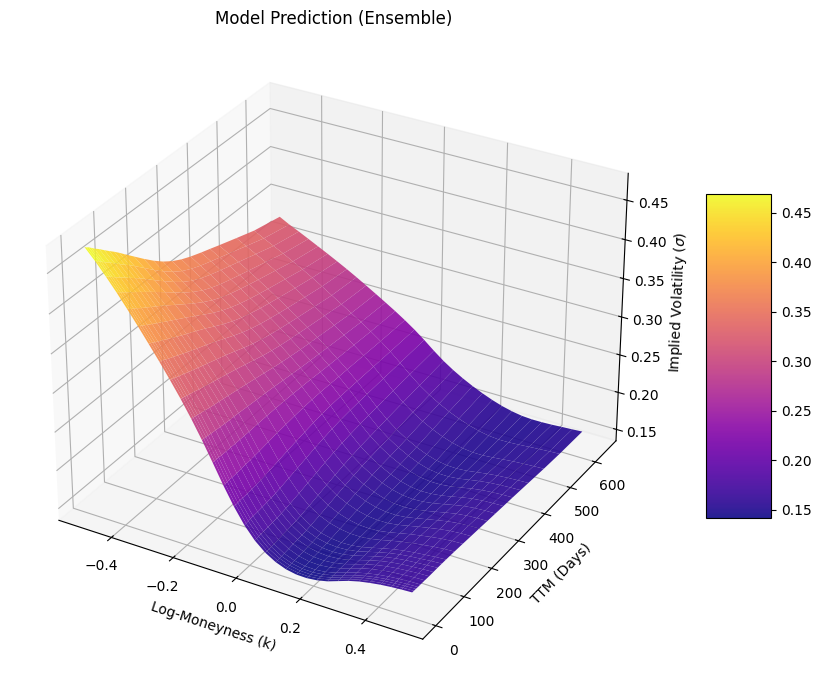

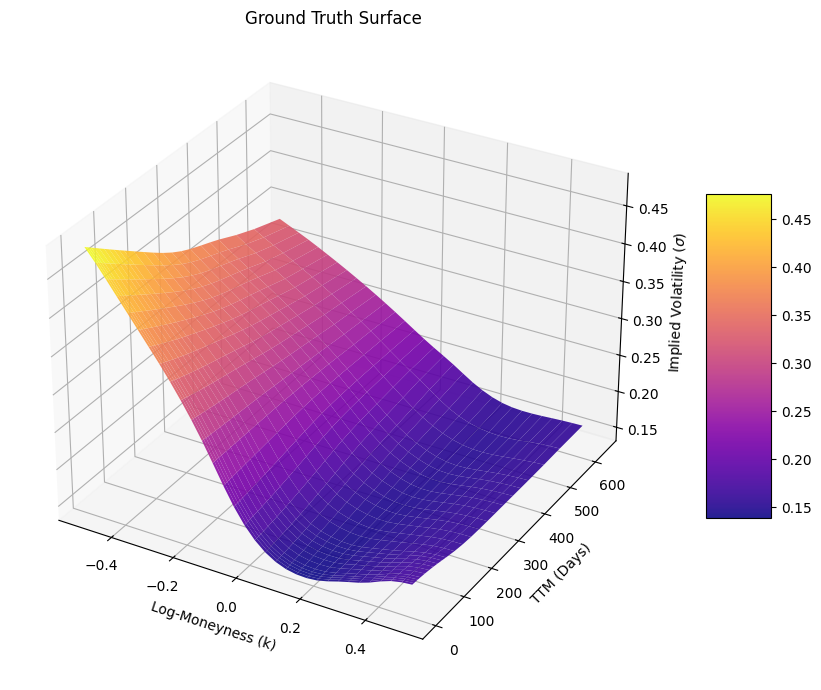

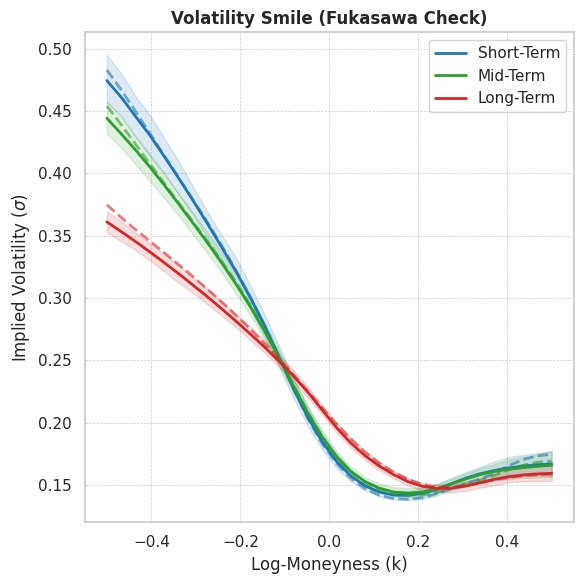

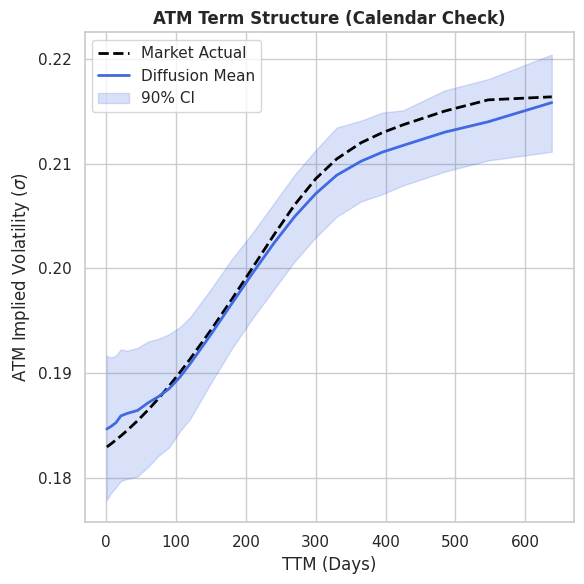

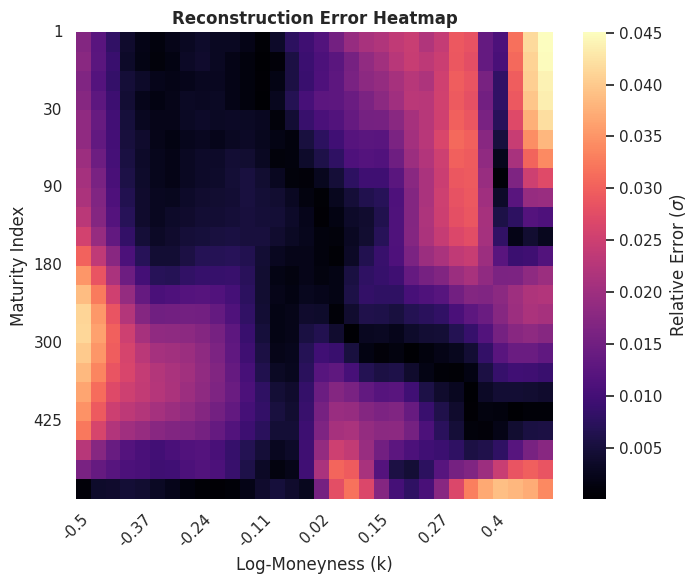

In [8]:
samples, ground_truth = runner.sample(day_idx=240, batch_size=100, num_steps=500)

scaled_back_real = ((ground_truth[:, :, :] * std) + mean).exp()
scaled_back = ((samples * std) + mean).exp()
plot_3d_surface(
    scaled_back.mean(0).view(config.IMAGE_HEIGHT, config.IMAGE_WIDTH),
    k_grid=log_moneyness_grid,
    tau_grid=ttm_grid,
    title="Model Prediction (Ensemble)",
)
plot_3d_surface(
    scaled_back_real.view(config.IMAGE_HEIGHT, config.IMAGE_WIDTH),
    k_grid=log_moneyness_grid,
    tau_grid=ttm_grid,
    title="Ground Truth Surface",
)

plot_day_surface_analysis(scaled_back, scaled_back_real, log_moneyness_grid, ttm_grid, separate_plots=True)

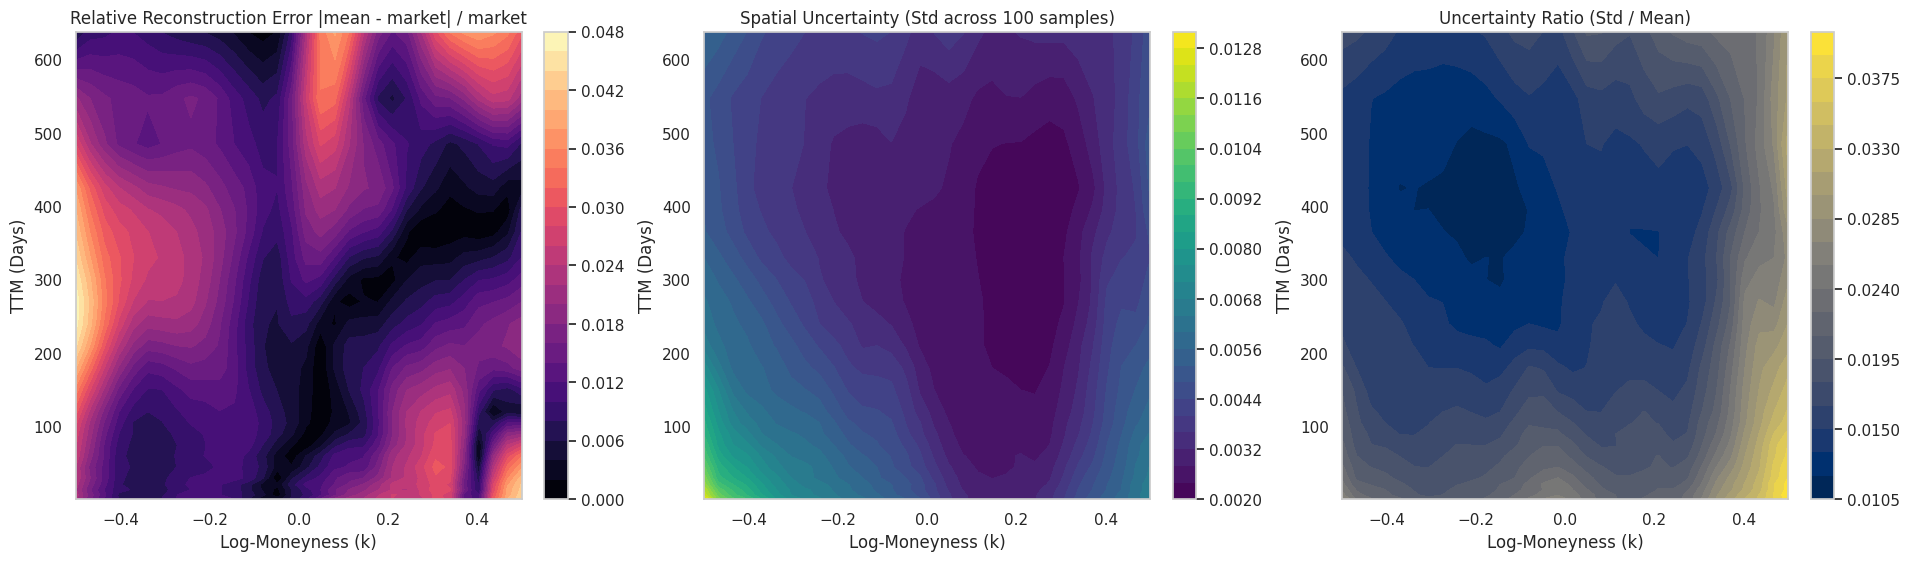

Avg uncertainty in illiquid region: 0.006912899203598499
Avg uncertainty elsewhere: 0.004015566781163216
Uncertainty ratio (illiquid / elsewhere): 1.7215251922607422
Avg relative error in illiquid region: 0.019159728661179543
Avg relative error elsewhere: 0.014321188442409039


In [9]:
def analyze_checkpoint_uncertainty(
    model: GNOTDiffusionLightningModule,
    *,
    day_idx: int,
    n_samples: int = 100,
    num_steps: int = 500,
    mean: torch.Tensor | float,
    std: torch.Tensor | float,
    log_moneyness_grid: torch.Tensor,
    ttm_grid: torch.Tensor,
    config: TrainingConfigConditionalDiffusion,
    eps: float = 1e-8,
    illiquid_abs_logk: float = 0.25,
    illiquid_ttm_max: float = 30.0,
    make_plot: bool = True,
) -> dict[str, torch.Tensor | np.ndarray | float]:
    """Sample from checkpoint and analyze spatial uncertainty/error against market surface."""
    h, w = config.IMAGE_HEIGHT, config.IMAGE_WIDTH
    mean_cpu = torch.as_tensor(mean).detach().cpu().float()
    std_cpu = torch.as_tensor(std).detach().cpu().float()

    samples_norm, gt_norm = runner.sample(day_idx=day_idx, batch_size=n_samples, num_steps=num_steps)

    samples_norm = torch.as_tensor(samples_norm).detach().cpu().float()
    gt_norm = torch.as_tensor(gt_norm).detach().cpu().float()

    # Handle common shape variants returned by sampling/targets.
    if samples_norm.ndim == 4 and samples_norm.shape[1] == 1:
        samples_norm = samples_norm[:, 0]  # (N, H, W)
    elif samples_norm.ndim != 3:
        samples_norm = samples_norm.reshape(n_samples, h, w)

    if gt_norm.ndim == 4 and gt_norm.shape[1] == 1:
        gt_norm = gt_norm[0, 0]  # (H, W)
    elif gt_norm.ndim == 3:
        gt_norm = gt_norm[0]
    elif gt_norm.ndim != 2:
        gt_norm = gt_norm.reshape(h, w)

    samples_iv = ((samples_norm * std_cpu) + mean_cpu).exp()  # (N, H, W)
    gt_iv = ((gt_norm * std_cpu) + mean_cpu).exp()  # (H, W)

    mean_iv = samples_iv.mean(dim=0)
    std_iv = samples_iv.std(dim=0, unbiased=False)
    var_iv = std_iv.pow(2)

    rel_err = (mean_iv - gt_iv).abs() / (gt_iv.abs() + eps)
    cv_map = std_iv / (mean_iv.abs() + eps)

    k = log_moneyness_grid.detach().cpu().numpy()
    t = ttm_grid.detach().cpu().numpy()

    if make_plot:
        fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), constrained_layout=True)

        m1 = axes[0].contourf(k, t, rel_err.numpy().T, levels=28, cmap="magma")
        axes[0].set_title("Relative Reconstruction Error |mean - market| / market")
        axes[0].set_xlabel("Log-Moneyness (k)")
        axes[0].set_ylabel("TTM (Days)")
        fig.colorbar(m1, ax=axes[0])

        m2 = axes[1].contourf(k, t, std_iv.numpy().T, levels=28, cmap="viridis")
        axes[1].set_title(f"Spatial Uncertainty (Std across {n_samples} samples)")
        axes[1].set_xlabel("Log-Moneyness (k)")
        axes[1].set_ylabel("TTM (Days)")
        fig.colorbar(m2, ax=axes[1])

        m3 = axes[2].contourf(k, t, cv_map.numpy().T, levels=28, cmap="cividis")
        axes[2].set_title("Uncertainty Ratio (Std / Mean)")
        axes[2].set_xlabel("Log-Moneyness (k)")
        axes[2].set_ylabel("TTM (Days)")
        fig.colorbar(m3, ax=axes[2])

        plt.show()

    k_mesh, t_mesh = np.meshgrid(k, t, indexing="xy")  # (len(t), len(k))
    illiquid_mask = (np.abs(k_mesh) >= illiquid_abs_logk) & (t_mesh <= illiquid_ttm_max)

    u = std_iv.numpy().T
    e = rel_err.numpy().T

    summary = {
        "avg_uncertainty_illiquid": float(u[illiquid_mask].mean()),
        "avg_uncertainty_elsewhere": float(u[~illiquid_mask].mean()),
        "uncertainty_ratio_illiquid_elsewhere": float(u[illiquid_mask].mean() / (u[~illiquid_mask].mean() + 1e-12)),
        "avg_rel_error_illiquid": float(e[illiquid_mask].mean()),
        "avg_rel_error_elsewhere": float(e[~illiquid_mask].mean()),
    }

    print("Avg uncertainty in illiquid region:", summary["avg_uncertainty_illiquid"])
    print("Avg uncertainty elsewhere:", summary["avg_uncertainty_elsewhere"])
    print(
        "Uncertainty ratio (illiquid / elsewhere):",
        summary["uncertainty_ratio_illiquid_elsewhere"],
    )
    print("Avg relative error in illiquid region:", summary["avg_rel_error_illiquid"])
    print("Avg relative error elsewhere:", summary["avg_rel_error_elsewhere"])

    return {
        "samples_iv": samples_iv,
        "gt_iv": gt_iv,
        "mean_iv": mean_iv,
        "std_iv": std_iv,
        "var_iv": var_iv,
        "rel_err": rel_err,
        "cv_map": cv_map,
        "k": k,
        "t": t,
        **summary,
    }


uncertainty_results = analyze_checkpoint_uncertainty(
    model,
    day_idx=240,
    n_samples=100,
    num_steps=500,
    mean=mean,
    std=std,
    log_moneyness_grid=log_moneyness_grid,
    ttm_grid=ttm_grid,
    config=config,
)

In [10]:
data_path = Path("/cluster/project/math/andtran/develop/masters_thesis/code/data/spx_options_data.parquet")

all_data = (
    pl.scan_parquet(data_path)
    .with_columns(pl.col("date").cast(pl.Date))
    .filter(
        pl.col("date").dt.year() >= 2010,
        pl.col("date").dt.year() <= 2023,  # noqa: PLR2004
        ~pl.col("isinterpolated"),
        pl.col("forward_price").is_not_null(),
    )
)
df_data = (
    all_data.with_columns(days_to_expiry=(pl.col("option_expiration").cast(pl.Date) - pl.col("date")).dt.total_days())
    .filter(
        ((pl.col("call_put") == "P") & (pl.col("strike") < pl.col("forward_price")))
        | ((pl.col("call_put") == "C") & (pl.col("strike") >= pl.col("forward_price")))
    )
    .drop(["day", "year", "month", "isinterpolated", "exchange", "company_name"])
    .with_columns(
        log_moneyness=(pl.col("strike") / pl.col("forward_price")).log(),
        moneyness=(pl.col("strike") / pl.col("forward_price")),
    )
).filter((pl.col("vega") > 0) & (pl.col("iv") > 0), pl.col("open_interest") > 0)

In [ ]:
date_to_viz = dt.date(2022, 6, 1)
date_to_viz_idx = find_dates_index(dates_df, date_to_viz)

# 1. Get your data (all at 71 days expiry)
df_day: pl.DataFrame = (
    df_data.filter(
        pl.col("date") == date_to_viz,
        pl.col("log_moneyness").is_between(-0.5, 0.5),
        pl.col("open") > 0,
        pl.col("days_to_expiry") < 639,
        pl.col("days_to_expiry") > 20,
    )
    .sort("days_to_expiry", "log_moneyness")
    .collect(engine="streaming")
)  # ty:ignore[invalid-assignment]


display(df_day)
x_t, iv_grid_norm, mask, query_coords = run_gnot_inpaint_slice(
    model,
    df_day,
    date_to_viz_idx - cut_off_train_idx - 1,
    0.5,
    scheduler,
    dataset_val,
    config,
    mean,
    std,
    device,
    log_moneyness_grid,
    ttm_grid,
)

date,symbol,stock_price_close,option_symbol,option_expiration,strike,call_put,style,open,high,low,close,bid,ask,mean_price,settlement,iv,volume,open_interest,stock_price_for_iv,forward_price,delta,vega,gamma,theta,rho,days_to_expiry,log_moneyness,moneyness
date,str,f64,str,str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
2022-06-01,"""SPX""",4101.23,"""SPXW 220622P03000000""","""2022-06-22""",3000.0,"""P""","""E""",1.0,1.0,1.0,1.0,0.6,0.75,0.675,0.0,0.505751,3.0,141.0,4099.113,4099.113,-0.004213,0.121924,0.000025,-0.146872,-0.010392,21,-0.312158,0.731866
2022-06-01,"""SPX""",4101.23,"""SPXW 220622P03200000""","""2022-06-22""",3200.0,"""P""","""E""",1.3,1.3,1.3,1.3,1.0,1.2,1.1,0.0,0.434511,3.0,6.0,4099.113,4099.113,-0.00758,0.205355,0.000049,-0.212525,-0.018642,21,-0.24762,0.780657
2022-06-01,"""SPX""",4101.23,"""SPXW 220622P03300000""","""2022-06-22""",3300.0,"""P""","""E""",1.79,1.79,1.74,1.74,1.35,1.5,1.425,0.0,0.399214,3.0,79.0,4099.113,4099.113,-0.010361,0.270069,0.00007,-0.256793,-0.025448,21,-0.216848,0.805052
2022-06-01,"""SPX""",4101.23,"""SPXW 220622P03350000""","""2022-06-22""",3350.0,"""P""","""E""",1.45,2.19,1.4,1.99,1.55,1.75,1.65,0.0,0.38225,418.0,371.0,4099.113,4099.113,-0.012306,0.313615,0.000085,-0.285524,-0.030205,21,-0.20181,0.81725
2022-06-01,"""SPX""",4101.23,"""SPXW 220622P03400000""","""2022-06-22""",3400.0,"""P""","""E""",2.15,2.45,2.15,2.45,1.85,2.05,1.95,0.0,0.36615,67.0,65.0,4099.113,4099.113,-0.014868,0.369229,0.000104,-0.321995,-0.036474,21,-0.186995,0.829448
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2022-06-01,"""SPX""",4101.23,"""SPX 231215C06000000""","""2023-12-15""",6000.0,"""C""","""E""",21.8,22.04,21.8,22.04,21.0,23.4,22.2,0.0,0.175656,5.0,12940.0,4198.807,4198.807,0.063113,6.19781,0.000141,-0.0953,4.208448,562,0.356959,1.428977
2022-06-01,"""SPX""",4101.23,"""SPX 231215C06100000""","""2023-12-15""",6100.0,"""C""","""E""",20.2,20.2,19.04,19.04,18.3,20.6,19.45,0.0,0.177124,44.0,10107.0,4198.807,4198.807,0.05593,5.637698,0.000127,-0.087478,3.744056,562,0.373488,1.452794
2022-06-01,"""SPX""",4101.23,"""SPX 231215C06200000""","""2023-12-15""",6200.0,"""C""","""E""",16.16,16.16,16.07,16.07,15.9,18.0,16.95,0.0,0.178338,2.0,12061.0,4198.807,4198.807,0.049363,5.105634,0.000114,-0.079822,3.318458,562,0.389749,1.47661


500it [00:08, 60.38it/s]


Day 240 Trace: 16it [00:00, 81.28it/s]

Day 240 Trace: 500it [00:04, 102.23it/s]


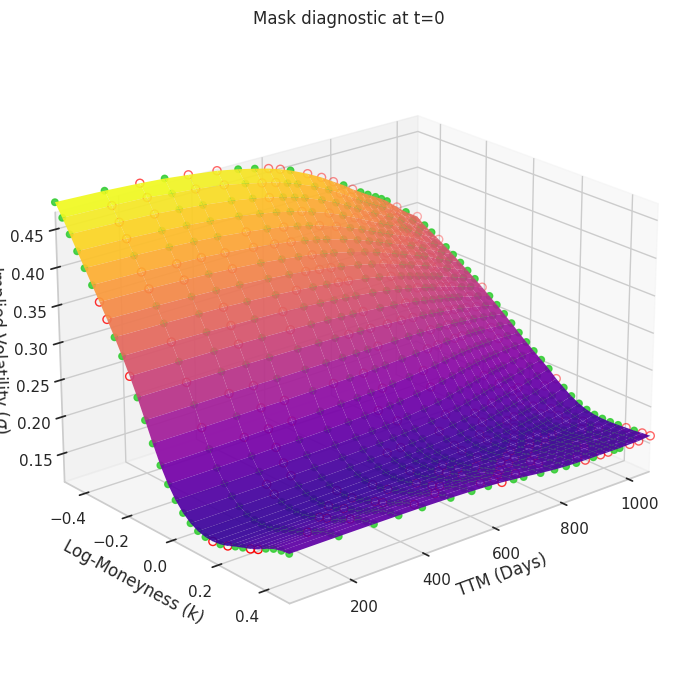

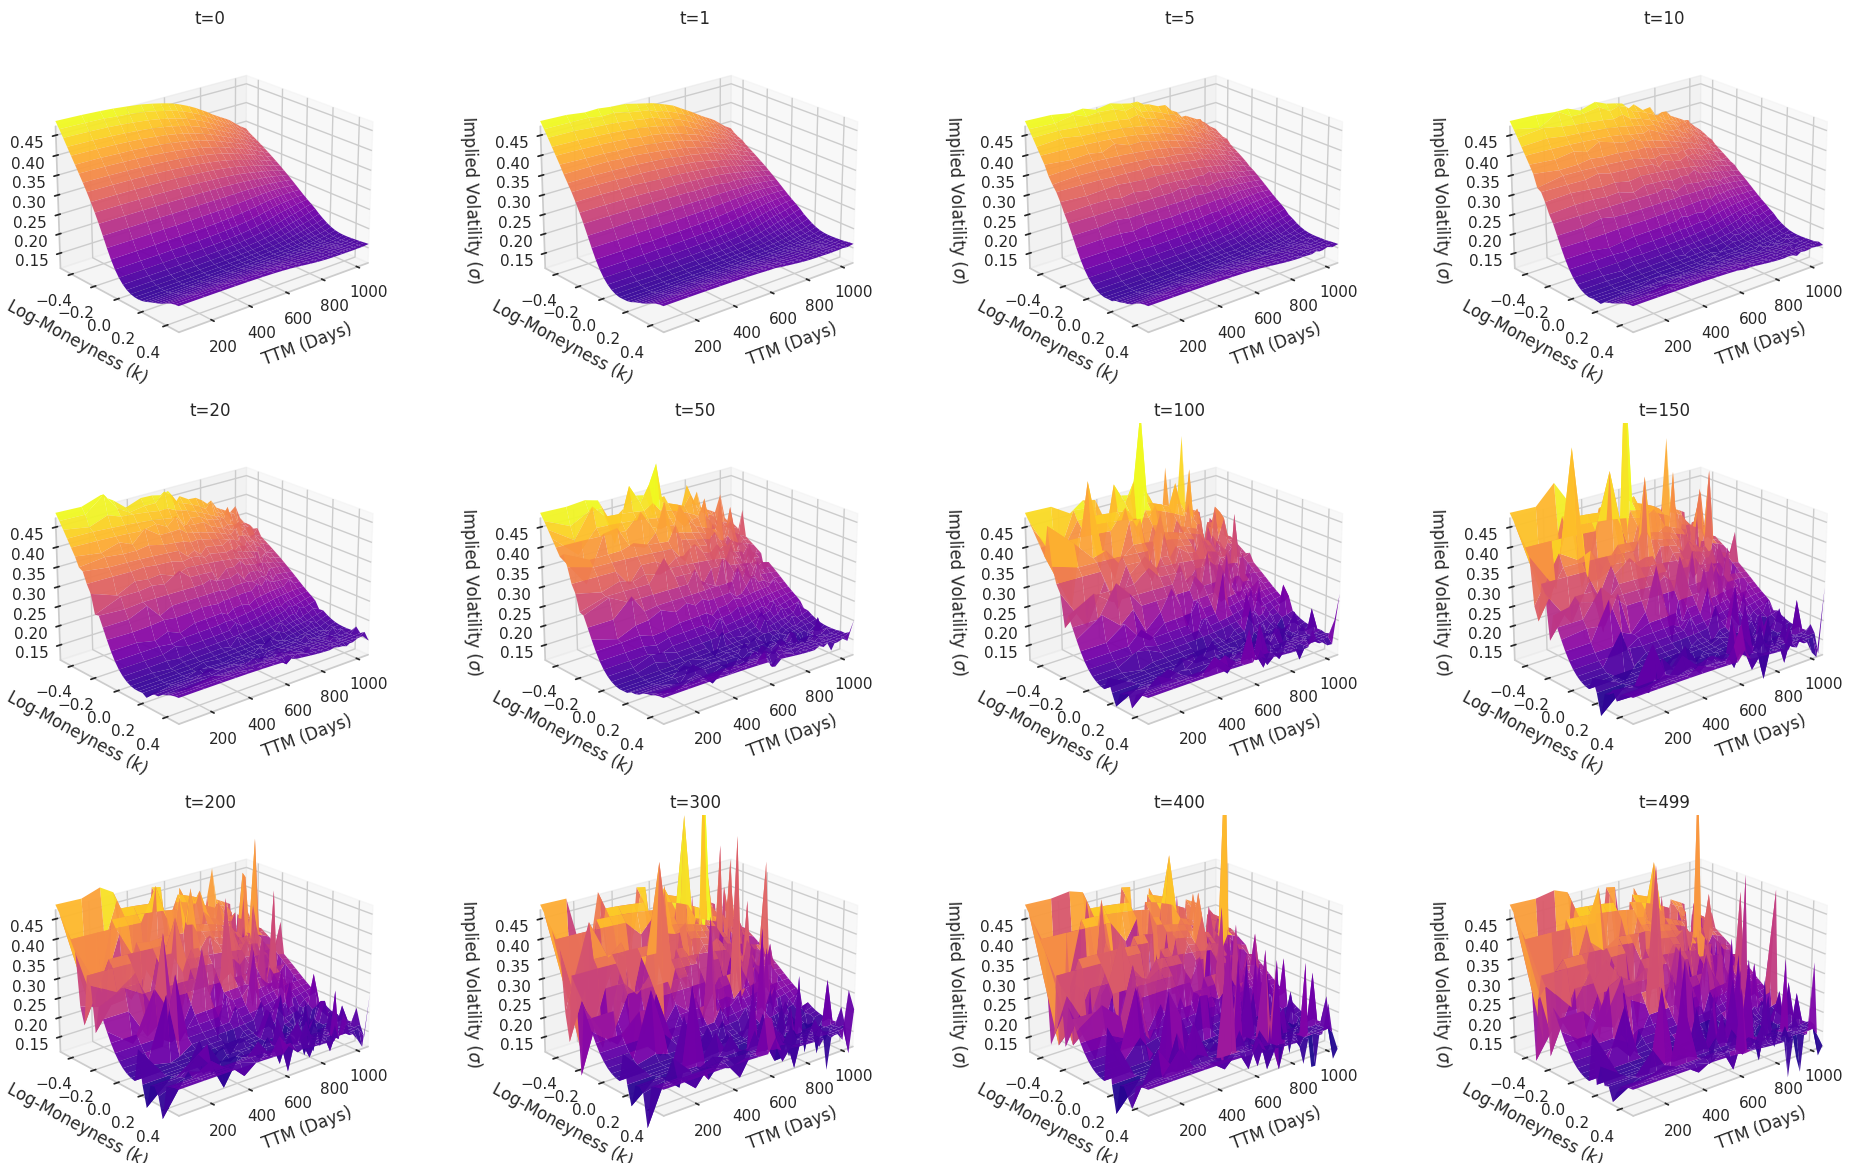

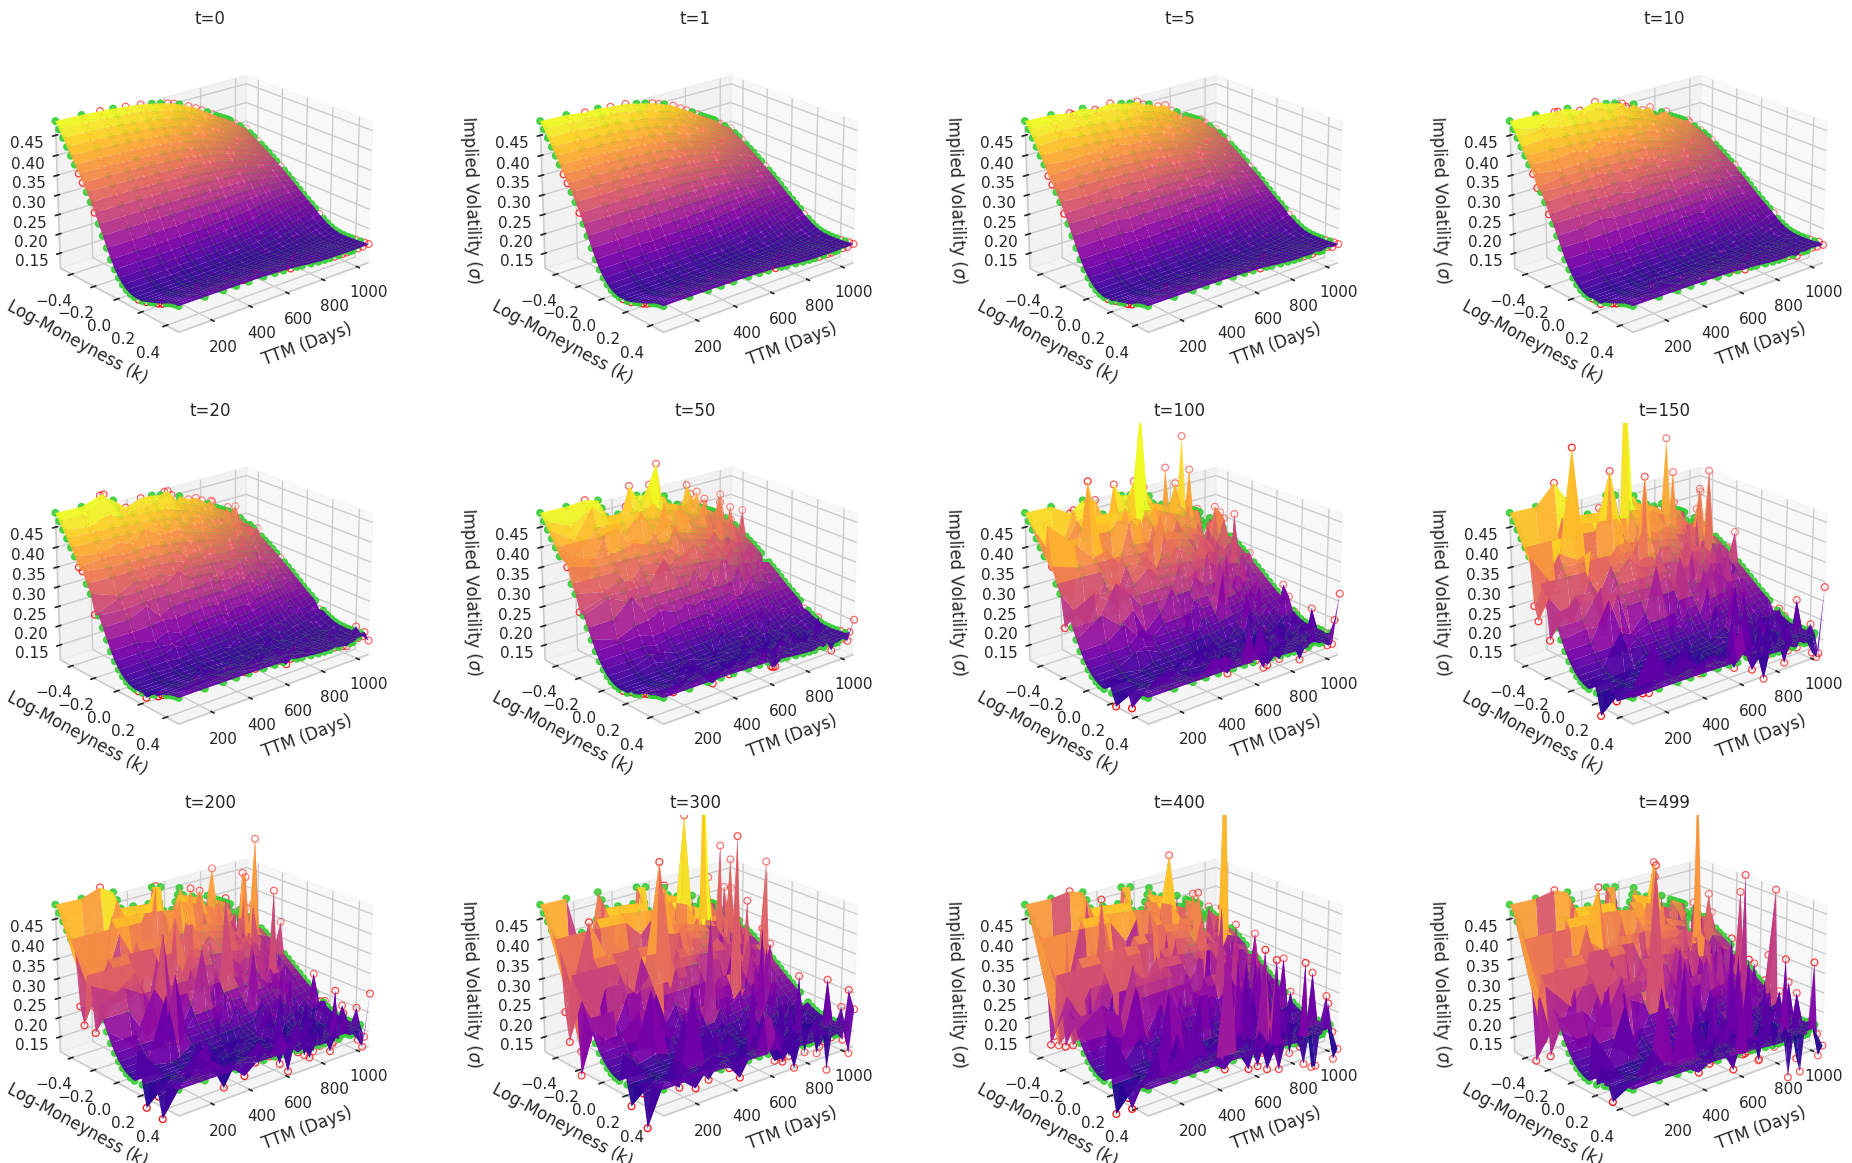

In [11]:
requested_ts = [0, 1, 5, 10, 20, 50, 100, 150, 200, 300, 400, 499]
val_day_idx = 240


trace_result = runner.inpaint_trace(
    day_idx=val_day_idx,
    prob=0.3,
    capture_ts=requested_ts,
    # scalars_override_raw=scalars_override  # Uncomment to test overriding
)
snapshots = trace_result.snapshots
target_img = trace_result.target_img
mask_img = trace_result.mask_img
query_coords = trace_result.coords
val_mean = trace_result.data_mean
val_std = trace_result.data_std

shared_limits = get_shared_limits(
    snapshots=snapshots,
    query_coords=query_coords,
    mean=val_mean,
    std=val_std,
    timesteps=requested_ts,
    robust=True,
)

fig_mask = plot_phase1_mask_reference(
    snapshots=snapshots,
    query_coords=query_coords,
    mask=mask_img,
    mean=val_mean,
    std=val_std,
    t_ref=0,
    axis_limits=shared_limits,
)

fig_progress = plot_phase1_surface_progress(
    snapshots=snapshots,
    query_coords=query_coords,
    mean=val_mean,
    std=val_std,
    timesteps=requested_ts,
    ncols=4,
    axis_limits=shared_limits,
)

fig_combined = plot_phase1_surface_progress_with_mask(
    snapshots=snapshots,
    query_coords=query_coords,
    mask=mask_img,
    mean=val_mean,
    std=val_std,
    timesteps=requested_ts,
    ncols=4,
    show_points="both",
    axis_limits=shared_limits,
)

In [12]:
scenario_seed = 1234
# extreme cases if returns drop -> vix spikes up (leverage effect)
all_raw = torch.cat([train_scalars, all_scalars_val], dim=0).cpu().numpy()
vix_max_raw = float(all_raw[:, ConditioningScalarIndex.VIX].min())
ret_max_raw = float(all_raw[:, ConditioningScalarIndex.RET].min())
scenario_raw = {
    ConditioningScalarIndex.VIX: vix_max_raw,
    ConditioningScalarIndex.RET: ret_max_raw,
}

trace_base = runner.inpaint_trace(
    day_idx=val_day_idx,
    prob=1.0,
    random_seed=scenario_seed,
)
trace_scn = runner.inpaint_trace(
    day_idx=val_day_idx,
    prob=1.0,
    random_seed=scenario_seed,
    scalars_override_raw=scenario_raw,
)
snapshots_base = trace_base.snapshots
mask_base = trace_base.mask_img
query_coords_base = trace_base.coords
snapshots_scn = trace_scn.snapshots
mask_scn = trace_scn.mask_img
query_coords_scn = trace_scn.coords
mean = trace_scn.data_mean
std = trace_scn.data_std

base_t0 = _denorm_iv(snapshots_base[0], mean, std)
scn_t0 = _denorm_iv(snapshots_scn[0], mean, std)
print("VIX max raw:", vix_max_raw)
print("RET max raw:", ret_max_raw)
print("Mean abs IV change at t=0:", float(np.mean(scn_t0 - base_t0)))

Day 240 Trace: 22it [00:00, 101.07it/s]

Day 240 Trace: 500it [00:04, 103.44it/s]
Day 240 Trace: 500it [00:04, 103.63it/s]

VIX max raw: -0.2957265079021454
RET max raw: -0.11984055489301682
Mean abs IV change at t=0: 0.02454332821071148


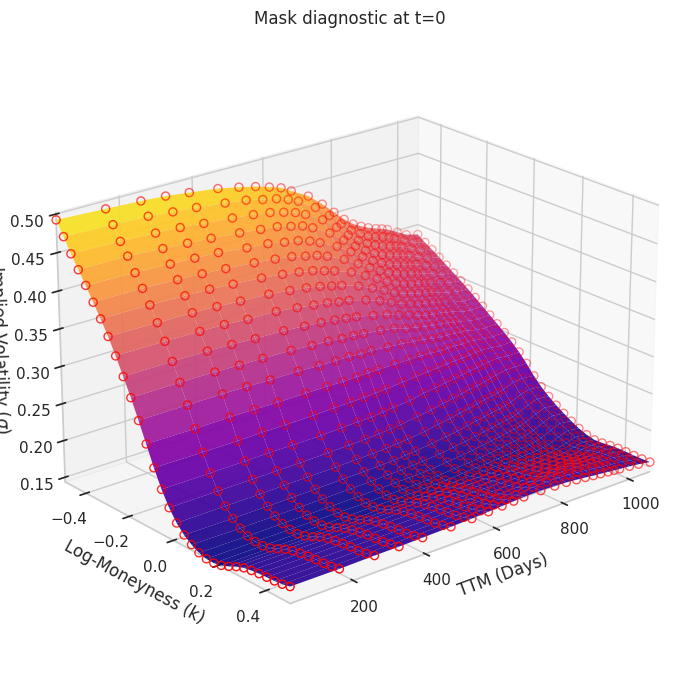

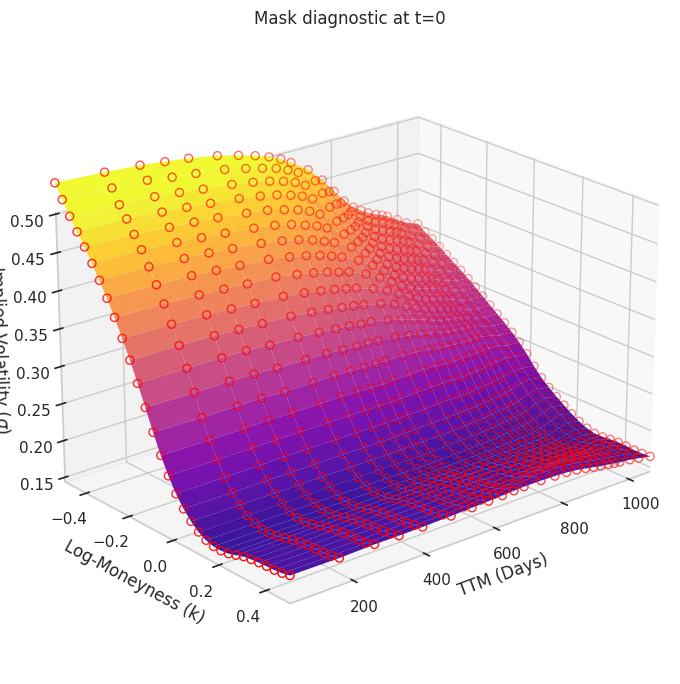

In [13]:
shared_limits = get_shared_limits(
    snapshots={0: snapshots_base[0], 1: snapshots_scn[0]},
    query_coords=query_coords_base,
    mean=mean,
    std=std,
    timesteps=[0, 1],
    robust=True,
)

# single-date comparison at t=0
fig_base = plot_phase1_mask_reference(
    snapshots=snapshots_base,
    query_coords=query_coords_base,
    mask=mask_base,
    mean=mean,
    std=std,
    t_ref=0,
    axis_limits=shared_limits,
)
fig_scn = plot_phase1_mask_reference(
    snapshots=snapshots_scn, query_coords=query_coords_scn, mask=mask_scn, mean=mean, std=std, t_ref=0, axis_limits=shared_limits
)

In [14]:
# Scenario setup
val_day_idx = 240
capture_ts = [0]  # only need final surface for now
scenario_seed = 1234
prob_all_masked = 1.0  # mask=1 everywhere

# Important: in run_gnot_inpaint_kernelized_trace override branch, make sure raw override is rescaled:
# scalars_np[0, idx] = (raw_val - scaler.mean_[idx]) / scaler.scale_[idx]

# Raw scalar pool (train + validation)
all_raw = torch.cat([train_scalars, all_scalars_val], dim=0).cpu().numpy()
ret_std = float(all_raw[:, ConditioningScalarIndex.RET].std(ddof=0))
ret_min = float(all_raw[:, ConditioningScalarIndex.RET].min())
ret_max = float(all_raw[:, ConditioningScalarIndex.RET].max())

# Current-date raw scalars from validation sample
_, _, _, scalars_day_scaled, _ = dataset_val[val_day_idx]
scalars_day_scaled_np = scalars_day_scaled.detach().cpu().numpy()
scalars_day_raw_np = scalars_day_scaled_np * scaler.scale_ + scaler.mean_

base_vix_raw = float(scalars_day_raw_np[ConditioningScalarIndex.VIX])
base_ret_raw = float(scalars_day_raw_np[ConditioningScalarIndex.RET])

# Return scenarios (VIX fixed)
scenario_ret_raw = {
    "base": base_ret_raw,
    "+1std": base_ret_raw + ret_std,
    "-1std": base_ret_raw - ret_std,
    "+3std": base_ret_raw + 3.0 * ret_std,
    "-3std": base_ret_raw - 3.0 * ret_std,
    "max": ret_max,
    "min": ret_min,
}

h, w = config.IMAGE_HEIGHT, config.IMAGE_WIDTH

# Outputs
scenario_surfaces = {}  # name -> (H, W) denormalized IV surface at t=0
scenario_runs = {}  # extra run artifacts if you need later

for name, ret_raw in scenario_ret_raw.items():
    overrides_raw = {
        ConditioningScalarIndex.VIX: base_vix_raw,  # fixed
        ConditioningScalarIndex.RET: ret_raw,  # varied
    }

    trace_result = runner.inpaint_trace(
        day_idx=val_day_idx,
        prob=prob_all_masked,
        capture_ts=capture_ts,
        scalars_override_raw=overrides_raw,
        random_seed=scenario_seed,
    )
    snapshots = trace_result.snapshots
    target_cpu = trace_result.target_img
    mask_cpu = trace_result.mask_img
    query_coords_cpu = trace_result.coords

    if 0 not in snapshots:
        raise ValueError(f"Scenario {name} missing t=0 snapshot.")

    surface_t0 = _denorm_iv(snapshots[0], mean, std).reshape(h, w)

    scenario_surfaces[name] = surface_t0
    scenario_runs[name] = {
        "ret_raw": ret_raw,
        "vix_raw": base_vix_raw,
        "snapshots": snapshots,
        "mask": mask_cpu,
        "query_coords": query_coords_cpu,
    }

    print(f"{name:>5} | ret_raw={ret_raw: .6f} | vix_raw={base_vix_raw: .6f}")

# Optional: precompute maturity slices for later plotting
logk_axis = log_moneyness_grid.detach().cpu().numpy()
ttm_axis = ttm_grid.detach().cpu().numpy()
scenario_slices = {
    name: {float(ttm_axis[j]): surf[:, j].copy() for j in range(len(ttm_axis))} for name, surf in scenario_surfaces.items()
}

Day 240 Trace: 500it [00:04, 102.61it/s]


 base | ret_raw=-0.008743 | vix_raw=-0.118776


Day 240 Trace: 500it [00:04, 103.72it/s]


+1std | ret_raw= 0.002314 | vix_raw=-0.118776


Day 240 Trace: 500it [00:04, 103.40it/s]


...

-3std | ret_raw=-0.041917 | vix_raw=-0.118776


Day 240 Trace: 500it [00:04, 103.48it/s]


  max | ret_raw= 0.093828 | vix_raw=-0.118776


Day 240 Trace: 500it [00:04, 103.39it/s]

  min | ret_raw=-0.119841 | vix_raw=-0.118776


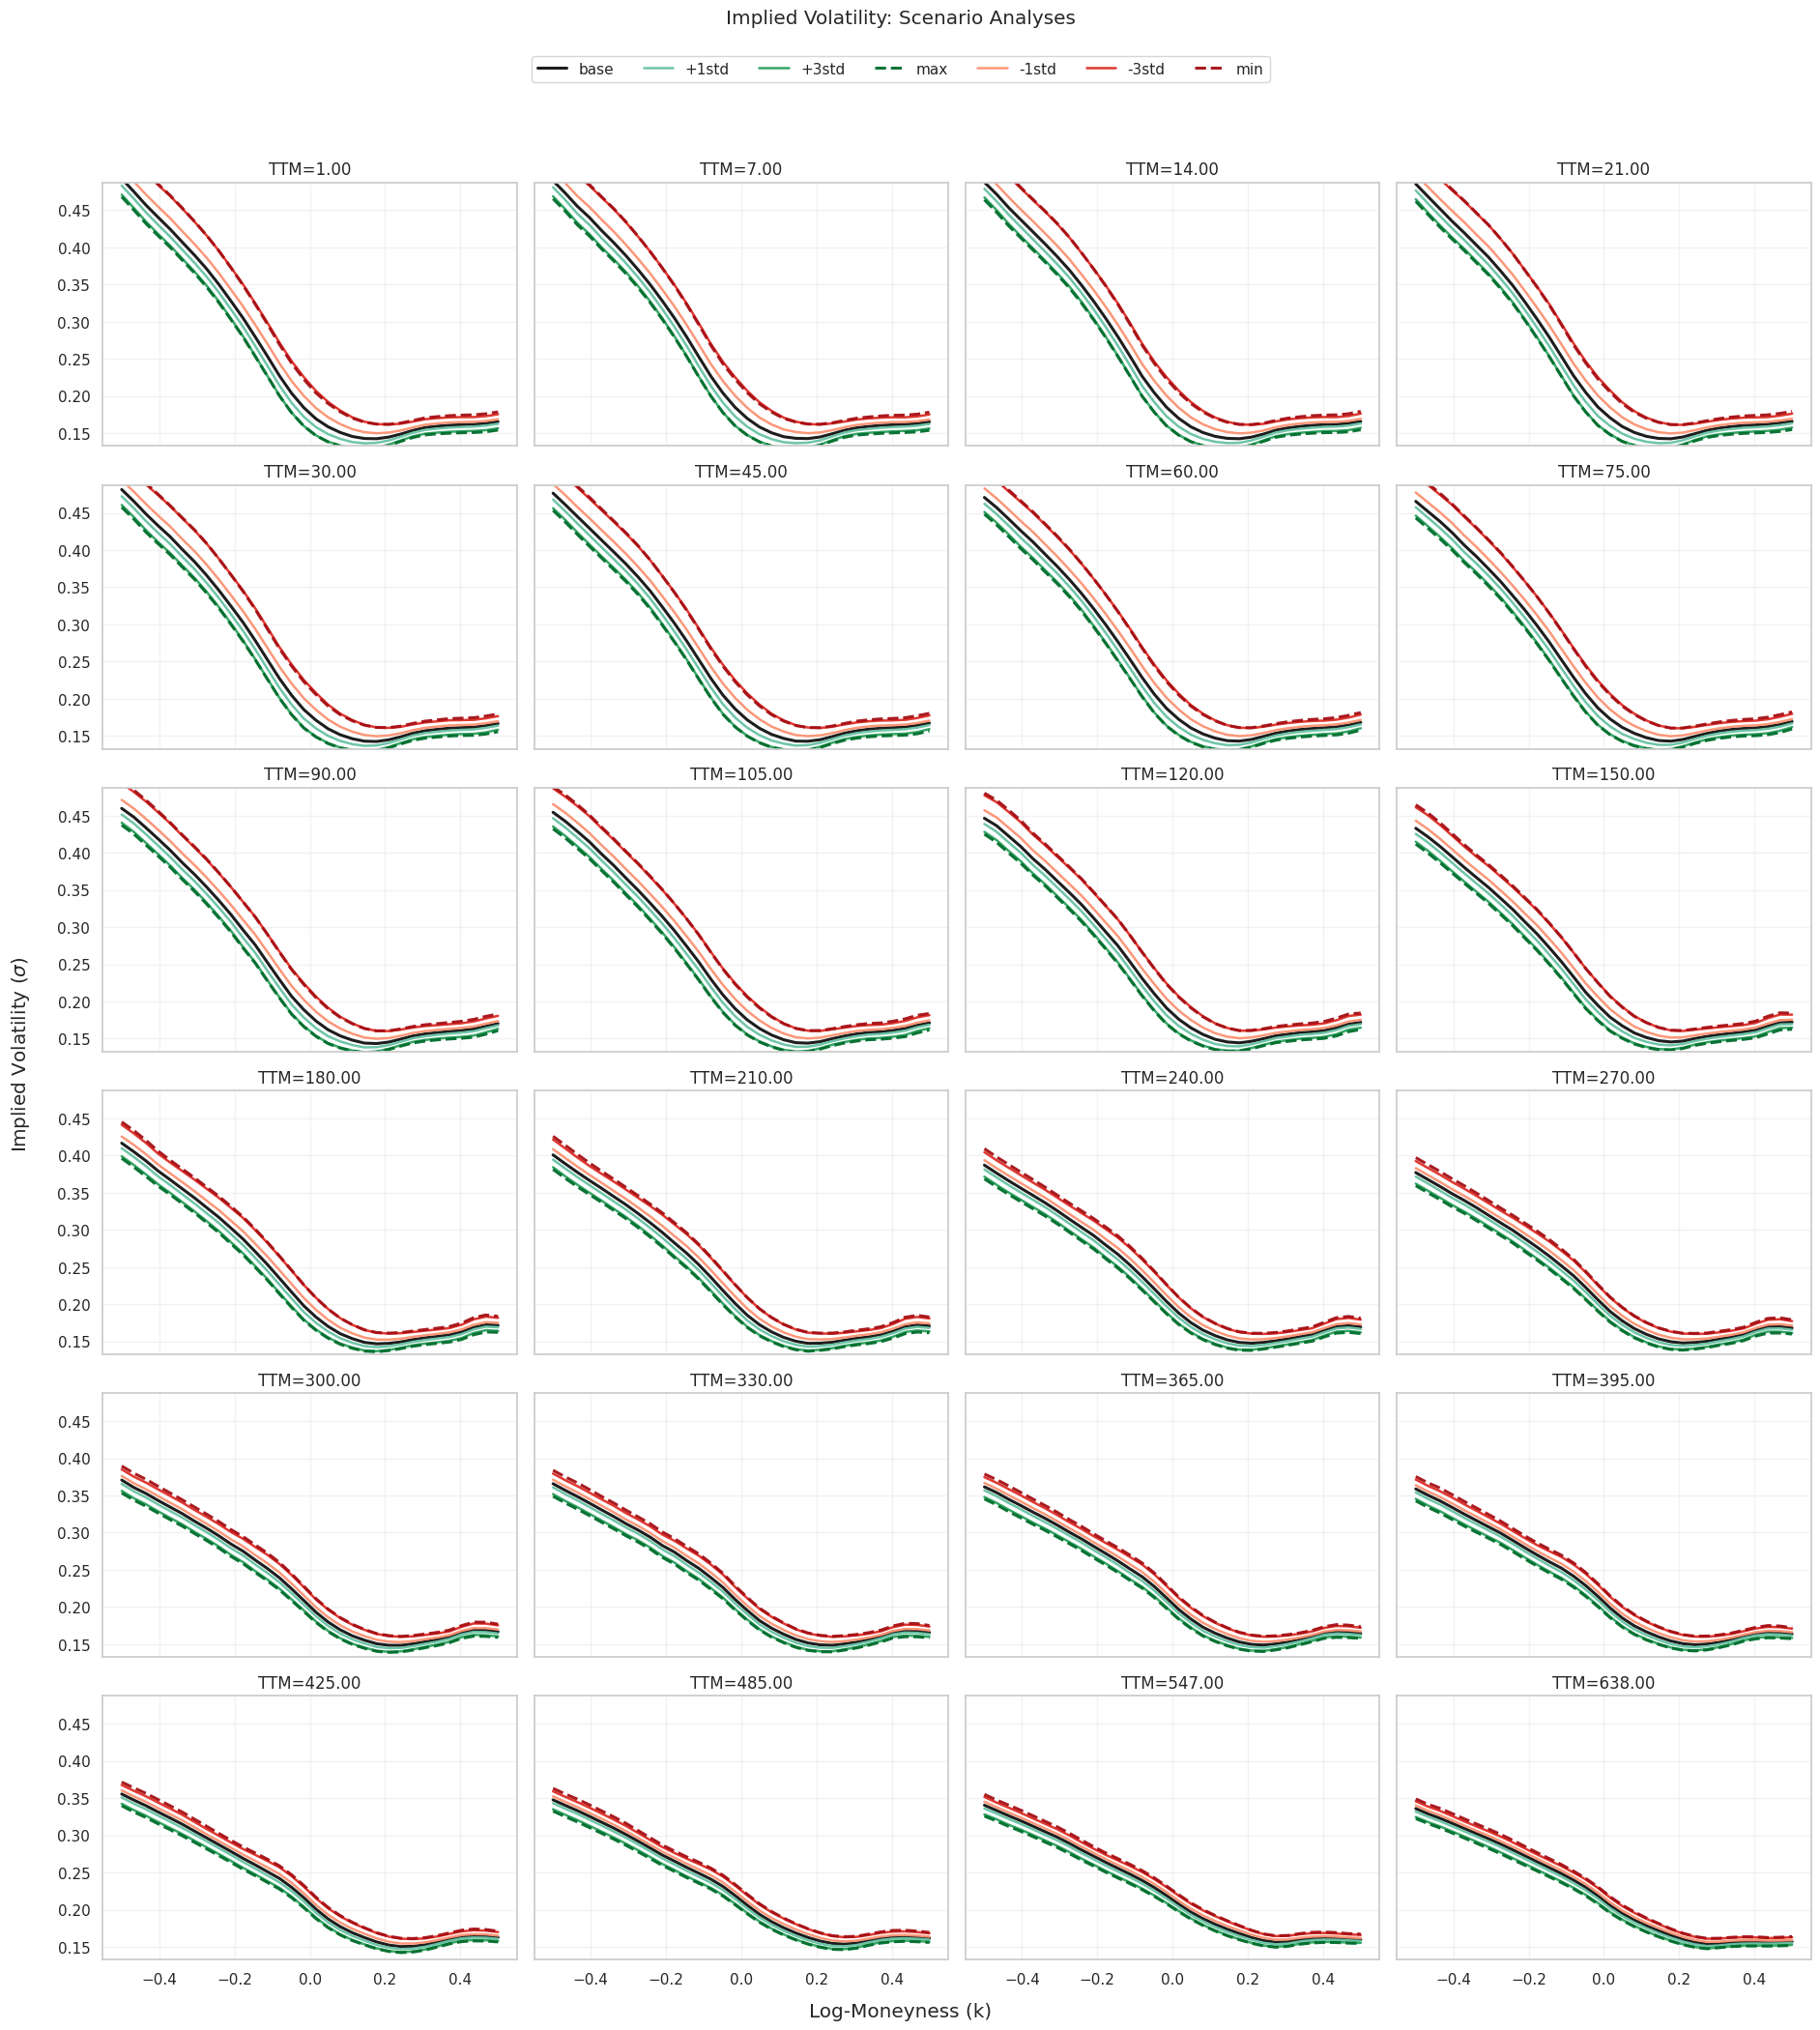

In [15]:
plot_scenario_slices(scenario_surfaces, logk_axis, ttm_axis)

In [16]:
# Step 1 run config (start small, then scale up).
MASK_PROBS_CURVE = [0.10, 0.30, 0.50, 0.70, 0.90]
MASK_PROBS_HEATMAP = [0.25, 0.50, 0.85]
MASK_PROBS_ALL = sorted(set(MASK_PROBS_CURVE + MASK_PROBS_HEATMAP))


N_EVAL_DAYS = 12  # increase to 25+ for final thesis numbers
BASE_SEED = 20260318


eval_day_indices = np.linspace(0, len(dataset_val) - 1, N_EVAL_DAYS, dtype=int).tolist()
print("Evaluating day indices:", eval_day_indices)


sparsity_metrics_df, sparsity_ape_maps = evaluate_rad_sparsity(
    model=model,
    scheduler=scheduler,
    dataset_val=dataset_val,
    config=config,
    log_moneyness_grid=log_moneyness_grid,
    mean=mean,
    std=std,
    device=device,
    ttm_grid=ttm_grid,
    scaler=scaler,
    mask_probs=MASK_PROBS_ALL,
    eval_day_indices=eval_day_indices,
    base_seed=BASE_SEED,
    eps=1e-8,
)


display(sparsity_metrics_df.head())
print(f"Runs completed: {len(sparsity_metrics_df)}")

Evaluating day indices: [0, 66, 132, 198, 264, 330, 397, 463, 529, 595, 661, 728]


Day 0 Trace: 500it [00:04, 102.65it/s]<?, ?it/s]
Day 66 Trace: 500it [00:04, 103.02it/s]00:53,  4.88s/it]
Day 132 Trace: 500it [00:04, 102.98it/s]0:48,  4.87s/it]
Day 198 Trace: 500it [00:04, 102.91it/s]0:43,  4.86s/it]
Day 264 Trace: 500it [00:04, 102.84it/s]0:38,  4.86s/it]
Day 330 Trace: 500it [00:04, 102.94it/s]0:34,  4.87s/it]
Day 397 Trace: 500it [00:04, 103.12it/s]0:29,  4.86s/it]
Day 463 Trace: 500it [00:04, 102.84it/s]0:24,  4.86s/it]
Day 529 Trace: 500it [00:04, 102.74it/s]0:19,  4.86s/it]
Day 595 Trace: 500it [00:04, 102.57it/s]0:14,  4.87s/it]
Day 661 Trace: 500it [00:04, 102.79it/s]00:09,  4.87s/it]
Day 728 Trace: 500it [00:04, 102.95it/s]00:04,  4.87s/it]
mask=10%: 100%|██████████| 12/12 [00:58<00:00,  4.87s/it]
Day 0 Trace: 500it [00:04, 102.71it/s]<?, ?it/s]
Day 66 Trace: 500it [00:04, 102.67it/s]00:53,  4.87s/it]
Day 132 Trace: 500it [00:04, 103.03it/s]0:48,  4.88s/it]
Day 198 Trace: 500it [00:04, 102.48it/s]0:43,  4.87s/it]
Day 264 Trace: 500it [00:04, 103.23it/s]0:39

,day_idx,mask_prob,mask_pct,global_mape,global_mse,short_tte_mape,mid_tte_mape,long_tte_mape,deep_otm_puts_mape,atm_near_money_mape,deep_otm_calls_mape
0,0,0.1,10.0,0.008688,6.053099e-09,0.005588,0.007364,0.010604,0.006271,0.005609,0.012989
1,66,0.1,10.0,0.006001,3.127960e-09,0.005954,0.005683,0.006228,0.005728,0.006855,0.008586
2,132,0.1,10.0,0.004904,1.804294e-09,0.004626,0.007237,0.003442,0.003816,0.004696,0.005777
3,198,0.1,10.0,0.009624,8.439804e-09,0.009564,0.005313,0.012518,0.007104,0.013120,0.011246
4,264,0.1,10.0,0.012376,1.317411e-08,0.025528,0.007760,0.011069,0.007843,0.007551,0.020274


Runs completed: 84


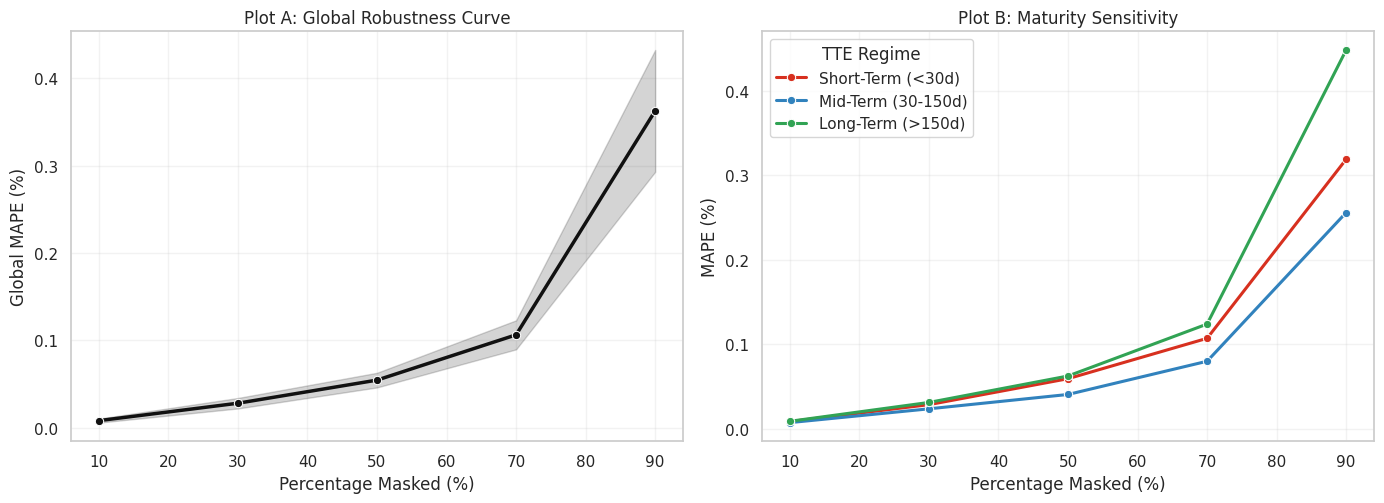

,Masking Ratio,Global MAPE,Short TTE (<30d),Mid TTE (30-150d),Long TTE (>150d),Deep OTM Puts,ATM / Near-The-Money,Deep OTM Calls
0,10%,0.01,0.01,0.01,0.01,0.01,0.01,0.01
1,30%,0.03,0.03,0.02,0.03,0.03,0.03,0.03
2,50%,0.05,0.06,0.04,0.06,0.05,0.05,0.06
3,70%,0.11,0.11,0.08,0.12,0.10,0.08,0.12
4,90%,0.36,0.32,0.26,0.45,0.26,0.31,0.51


In [17]:
sparsity_table_df = build_sparsity_table(sparsity_metrics_df, MASK_PROBS_CURVE)
plot_global_and_maturity_curves(sparsity_metrics_df, MASK_PROBS_CURVE)


display(
    sparsity_table_df.style.format(
        {
            "Global MAPE": "{:.2f}",
            "Short TTE (<30d)": "{:.2f}",
            "Mid TTE (30-150d)": "{:.2f}",
            "Long TTE (>150d)": "{:.2f}",
            "Deep OTM Puts": "{:.2f}",
            "ATM / Near-The-Money": "{:.2f}",
            "Deep OTM Calls": "{:.2f}",
        }
    )
)

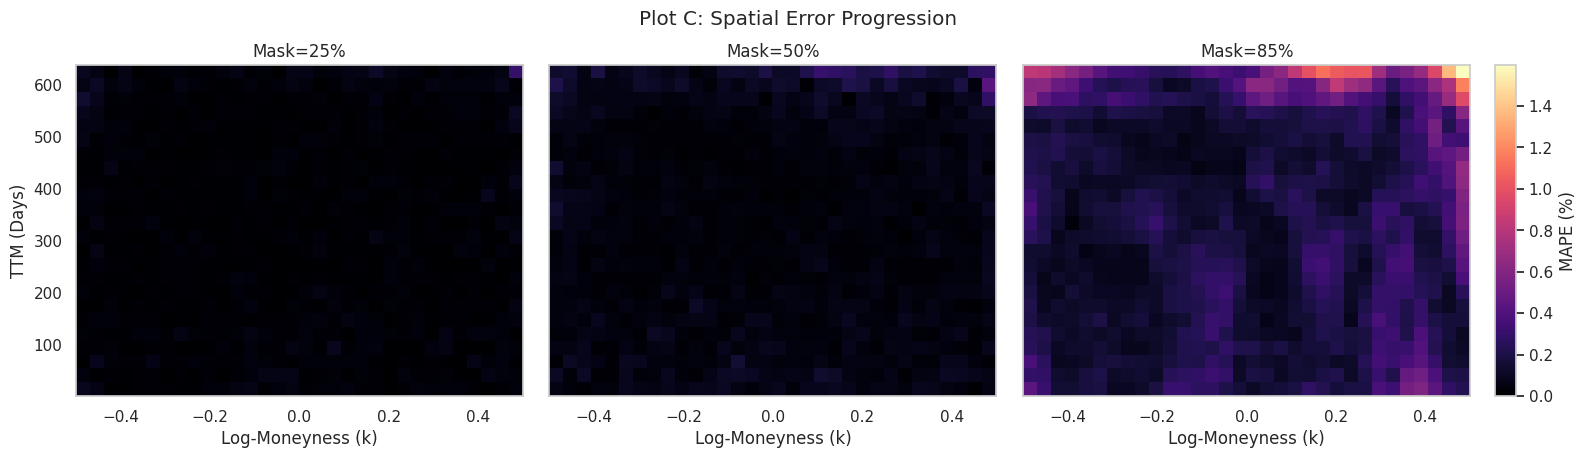

In [18]:
plot_spatial_error_progression(
    sparsity_ape_maps,
    log_moneyness_grid.detach().cpu().numpy(),
    ttm_grid.detach().cpu().numpy(),
    target_mask_probs=MASK_PROBS_HEATMAP,
)

## 5.1.5 Robustness to Extreme Sparsity (Graceful Degradation)


This section evaluates how RAD reconstruction degrades as quote coverage decreases.


Run the cells in order:


1. Define helper metrics + evaluation harness.
2. Run the sparsity sweep across mask levels.
3. Generate Plot A (global cliff) + Plot B (maturity sensitivity) + thesis table.
4. Generate Plot C (spatial error progression heatmaps).

In [ ]:
DAYS = 4
BATCH_SIZE = 8

preds_buffer, gt_buffer, day_indices_buffer = build_fullgrid_prediction_buffers(
    model=model,
    scheduler=scheduler,
    dataset_val=dataset_val,
    config=config,
    device=device,
    log_moneyness_grid=log_moneyness_grid,
    ttm_grid=ttm_grid,
    mean=mean,
    std=std,
    days_per_batch=DAYS,
    samples_per_day=BATCH_SIZE,
    tte_scale_factor=1095.0,
)

Full-grid validation:  56%|█████▋    | 103/183 [30:34<23:44, 17.81s/it]


KeyboardInterrupt: 

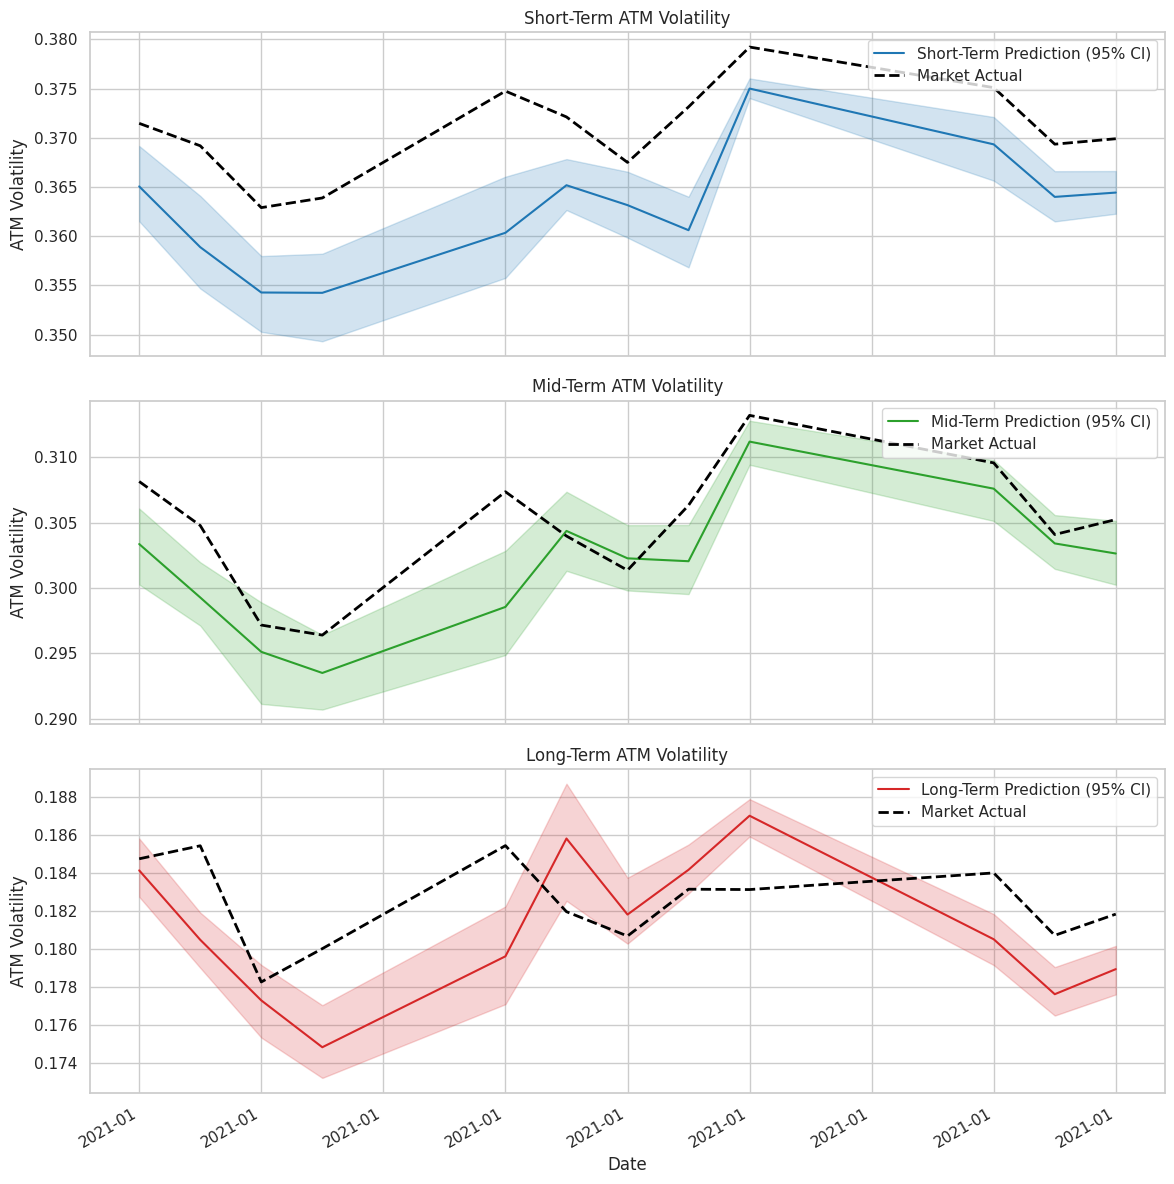

In [ ]:
indices = {"SHORT": 1, "MID": 8, "LONG": 18, "ATM": 16}
day_to_date = {i: pd.to_datetime(dataset_val.dates[i + 1]).date() for i in range(len(dataset_val))}
aggregate_and_plot(
    preds_buffer,
    gt_buffer,
    day_indices_buffer,
    indices,
    day_to_date=day_to_date,
    date_fmt="%Y-%m",
    date_tick_interval_months=6,
)

In [ ]:
calculate_and_plot_physics_metrics(
    preds_buffer,
    gt_buffer,
    day_indices_buffer,
    arb_loss,
    butterfly_loss,
    device=device,
    separate_plots=True,
    day_to_date=day_to_date,
    date_fmt="%Y-%m",
)

NameError: name 'preds_buffer' is not defined

## Kernelized Slice Grid (dataset_val)

This block evaluates the model on the kernelized validation set only (`dataset_val`) at a fixed masking rate.

It builds:
- A TTM slice grid (similar layout to `plot_scenario_slices`) showing market vs reconstructed smiles.
- A full-surface difference view to highlight where reconstruction deviates from the kernelized target.

Use smaller `N_DAYS` and `N_MC` for quick iteration, then scale up for final thesis plots.

Evaluating validation day indices: [0, 66, 132, 198, 264, 330, 397, 463, 529, 595, 661, 728]


Day 0 Trace: 500it [00:04, 103.36it/s]| 0/12 [00:00<?, ?it/s]
Day 66 Trace: 500it [00:04, 102.65it/s] 1/12 [00:04<00:53,  4.85s/it]
Day 132 Trace: 500it [00:04, 103.17it/s]2/12 [00:09<00:48,  4.87s/it]
Day 198 Trace: 500it [00:04, 102.88it/s]3/12 [00:14<00:43,  4.86s/it]
Day 264 Trace: 500it [00:04, 102.84it/s]4/12 [00:19<00:38,  4.86s/it]
Day 330 Trace: 500it [00:04, 103.05it/s]5/12 [00:24<00:34,  4.86s/it]
Day 397 Trace: 500it [00:04, 103.06it/s]6/12 [00:29<00:29,  4.86s/it]
Day 463 Trace: 500it [00:04, 103.24it/s]7/12 [00:34<00:24,  4.86s/it]
Day 529 Trace: 500it [00:04, 102.86it/s]8/12 [00:38<00:19,  4.86s/it]
Day 595 Trace: 500it [00:04, 103.00it/s]9/12 [00:43<00:14,  4.86s/it]
Day 661 Trace: 500it [00:04, 103.03it/s]10/12 [00:48<00:09,  4.86s/it]
Day 728 Trace: 500it [00:04, 102.58it/s]11/12 [00:53<00:04,  4.86s/it]
Kernelized eval p=80%: 100%|██████████| 12/12 [00:58<00:00,  4.86s/it]


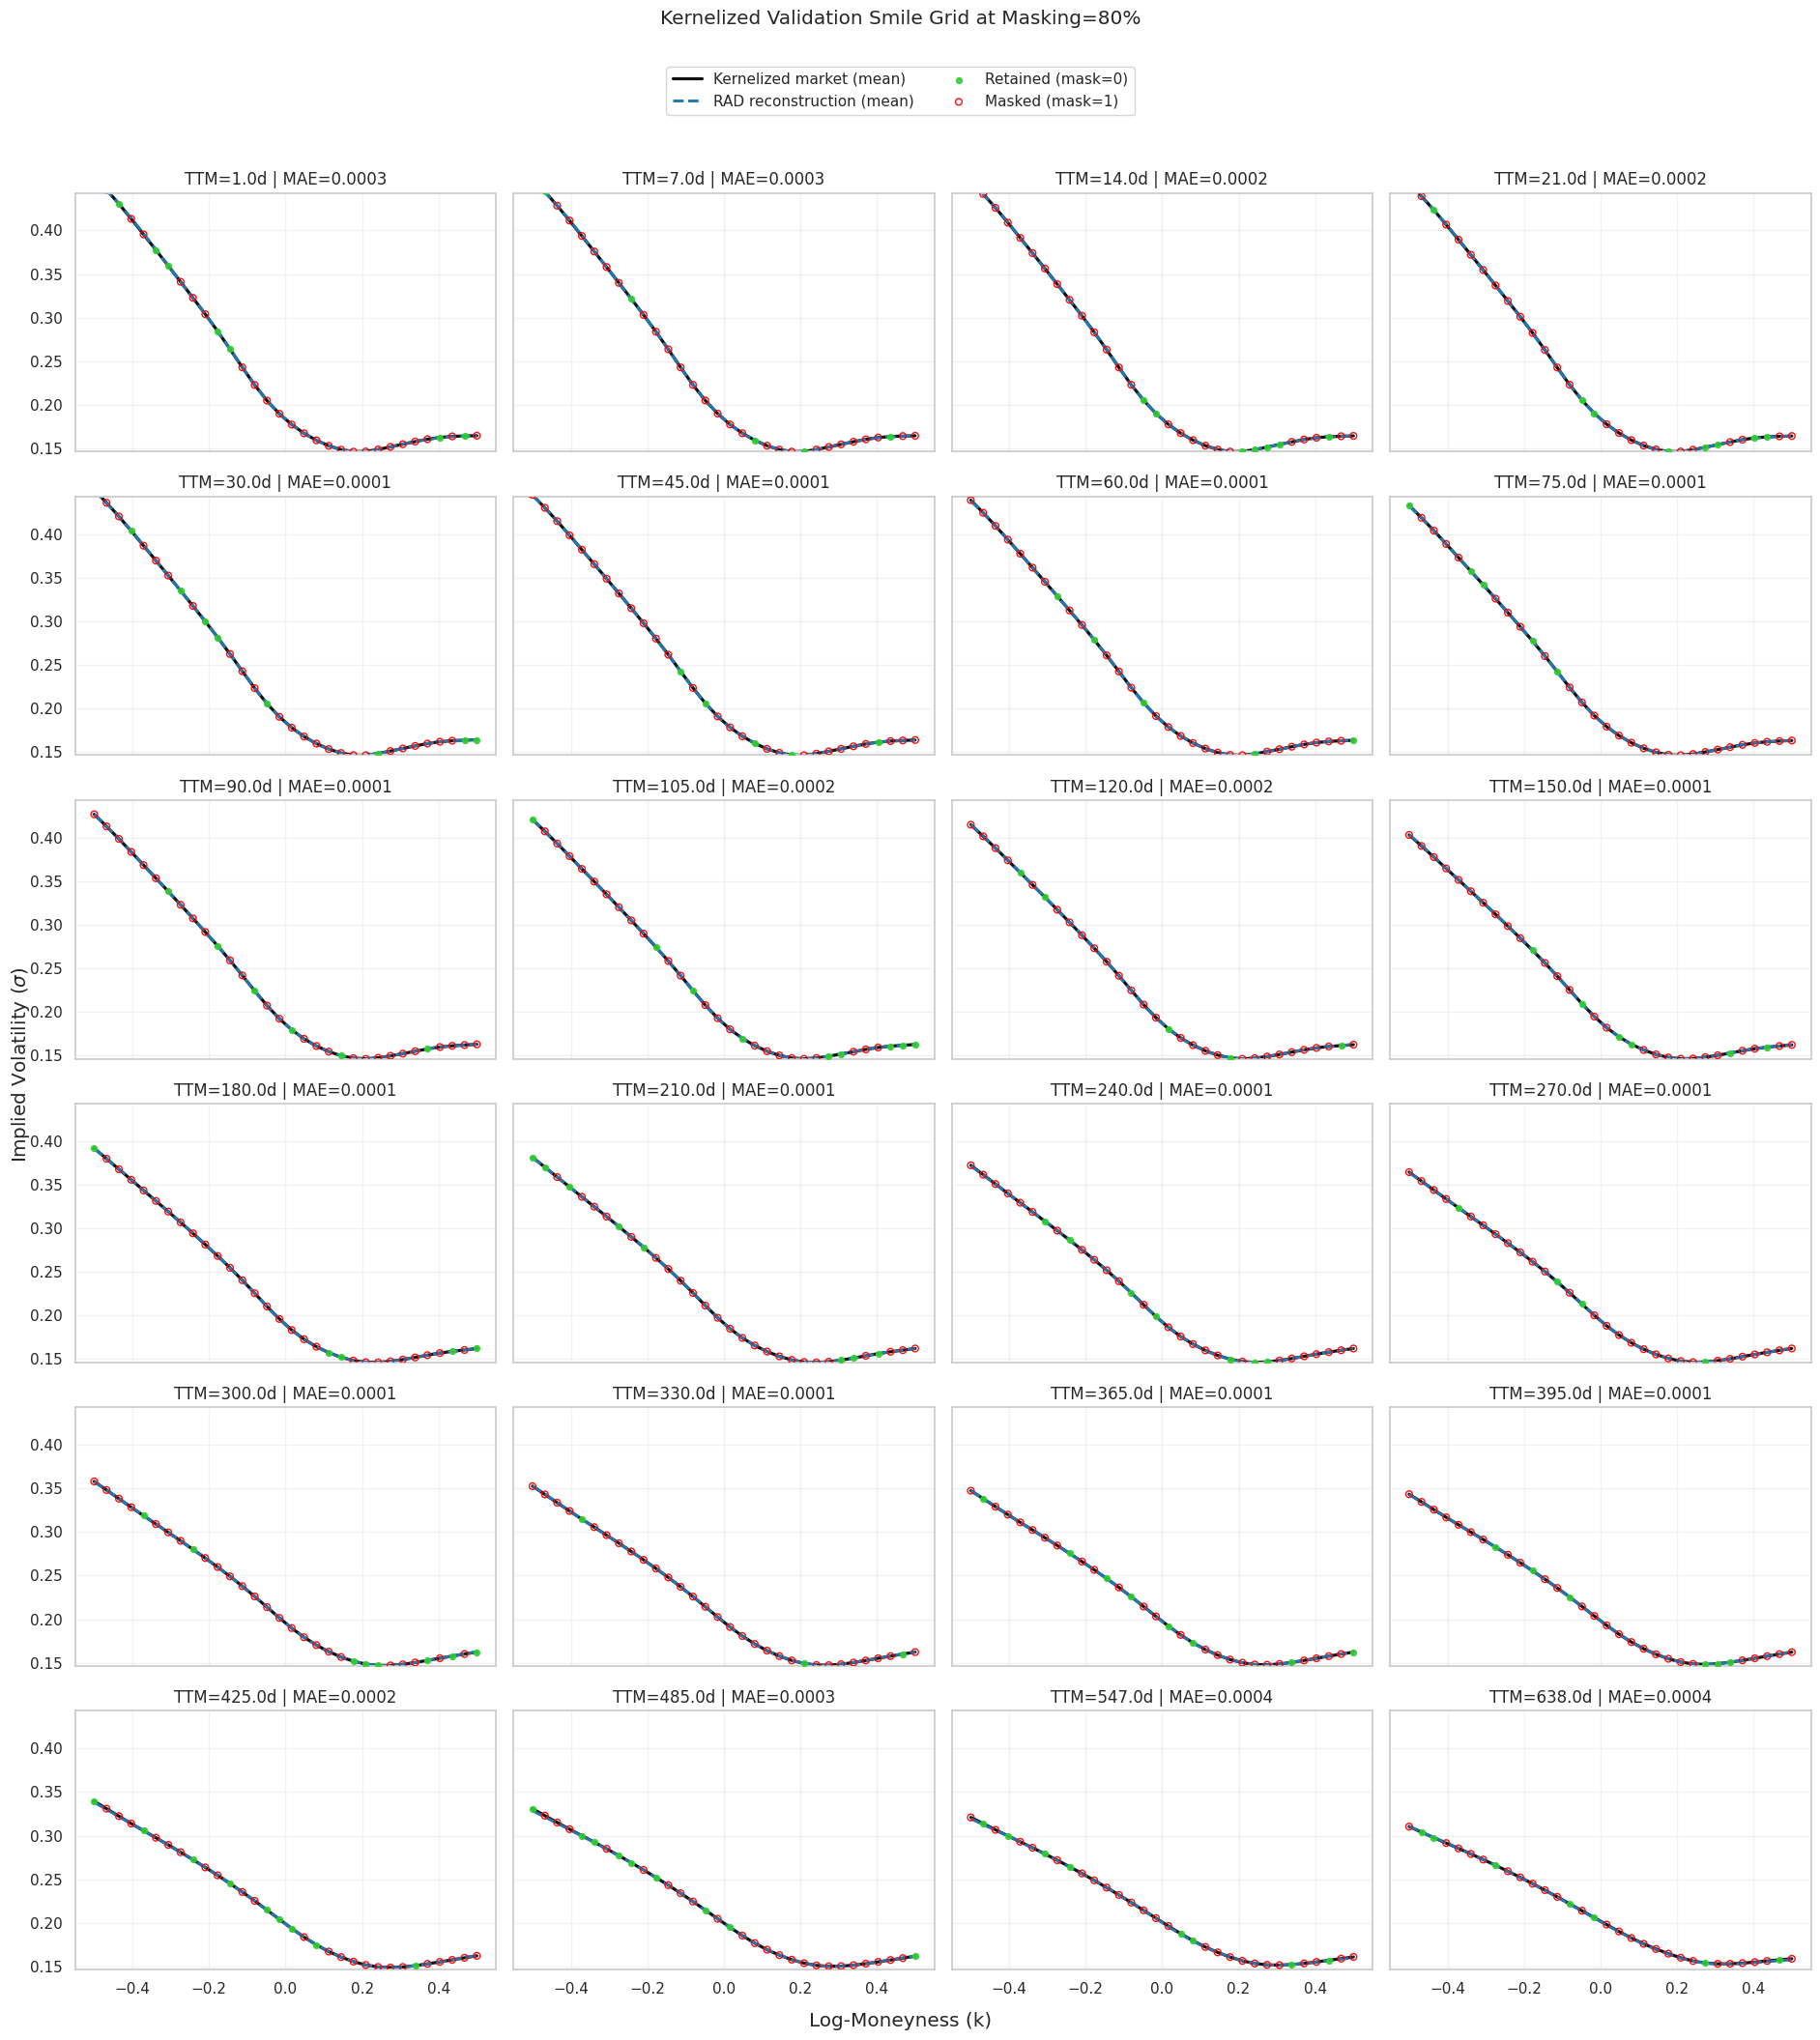

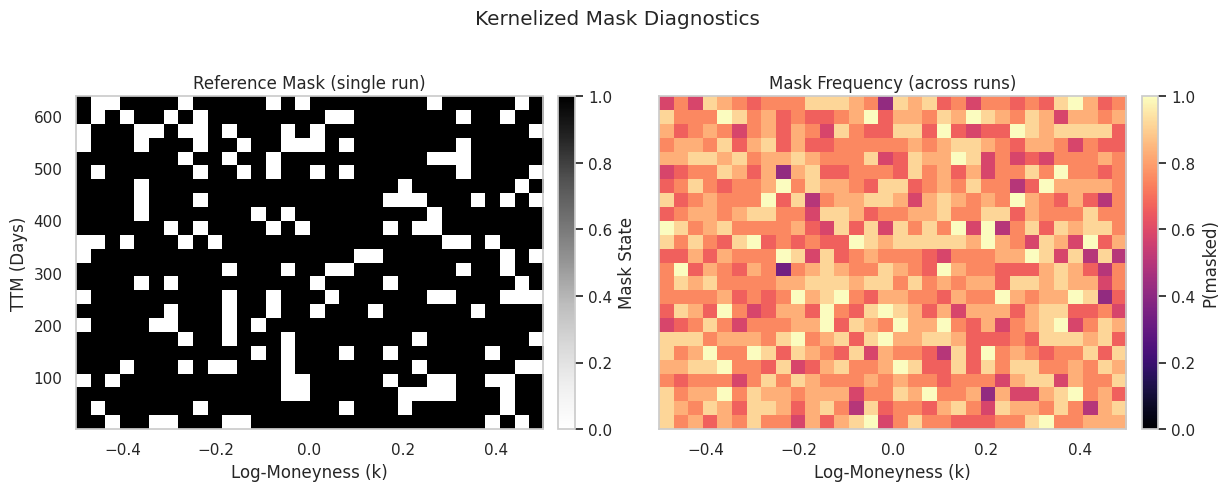

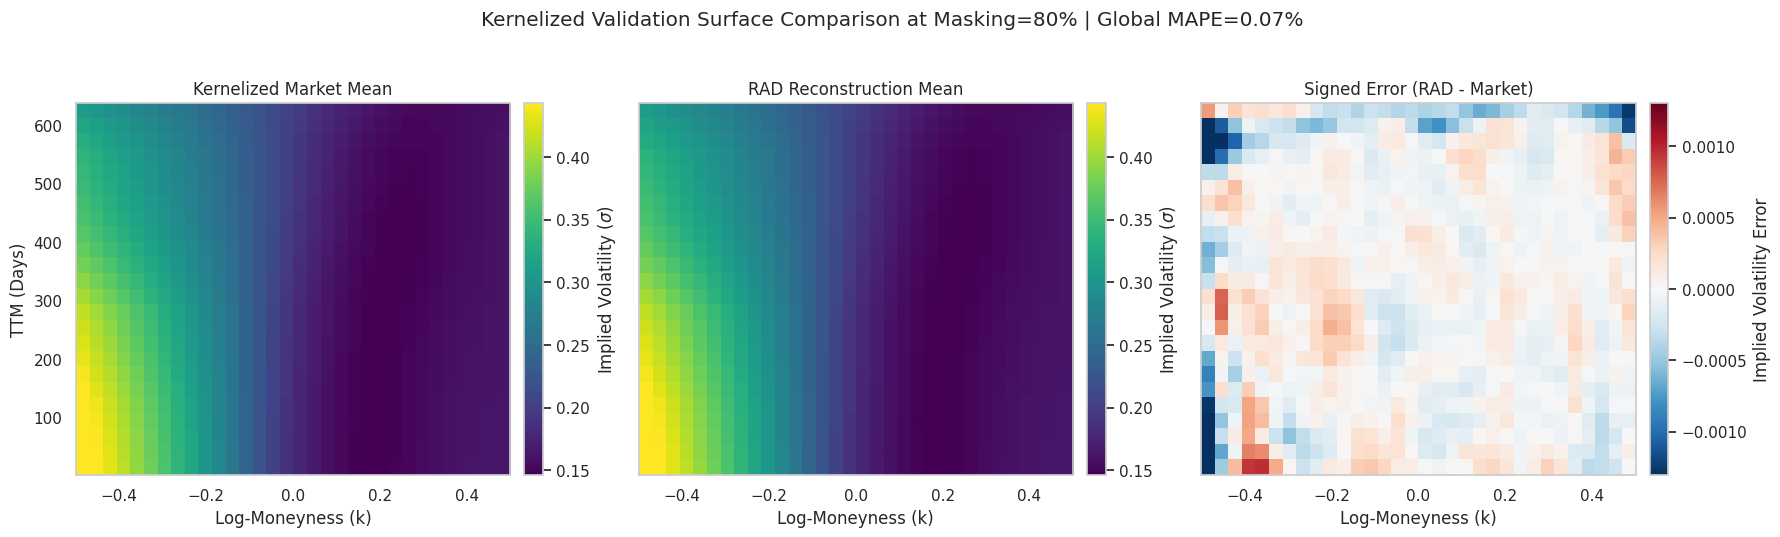

In [22]:
MASK_PROB = 0.8
N_DAYS = 12
N_MC = 1
BASE_SEED = 20260320

# Uniformly sample validation days to avoid time-cluster bias.
eval_day_indices = np.linspace(0, len(dataset_val) - 1, N_DAYS, dtype=int).tolist()
print("Evaluating validation day indices:", eval_day_indices)

kernelized_results = build_kernelized_slice_evaluation(
    mask_prob=MASK_PROB,
    eval_day_indices=eval_day_indices,
    n_mc=N_MC,
    base_seed=BASE_SEED,
    model=model,
    scheduler=scheduler,
    dataset_val=dataset_val,
    config=config,
    device=device,
    log_moneyness_grid=log_moneyness_grid,
    ttm_grid=ttm_grid,
    scaler=scaler,
    mean=mean,
    std=std,
)

ttm_indices = None

plot_kernelized_ttm_slice_grid(
    kernelized_results,
    n_cols=4,
    ttm_indices=ttm_indices,
    show_mask_points=True,
    mask_source="reference",
    mask_threshold=0.5,
)

plot_kernelized_mask_map(kernelized_results)
plot_kernelized_surface_difference(kernelized_results)

## Wing Extrapolation to +/-0.7 (No t+1 Leakage)

This block extrapolates a fixed surface to wider moneyness using the diffusion operator without using `next_surf` (`t+1`) as initialization.

Idea:
- Use only interior points (for example `|logk| <= 0.35`) as observed constraints.
- Keep those observed points frozen via the RAD mask (`mask=0`), and sample unknown points (`mask=1`) on an extended query grid (for example `[-0.7, 0.7]`).
- Compare two context modes:
  1. `surface_only`: duplicate the fixed surface across the 3 context branches.
  2. `history_context`: use `(surf_t, ema_short_t, ema_long_t)` from the dataset row (still no `t+1` leakage).

In [24]:
def _interp_surface_along_logk(
    surface_hw: torch.Tensor,
    logk_src: torch.Tensor,
    logk_dst: torch.Tensor,
) -> torch.Tensor:
    """Interpolate (K_src, T) to logk_dst; outside range uses edge values."""
    surface_np = surface_hw.detach().cpu().numpy()
    src_np = logk_src.detach().cpu().numpy()
    dst_np = logk_dst.detach().cpu().numpy()

    out = np.empty((len(dst_np), surface_np.shape[1]), dtype=np.float32)
    for j in range(surface_np.shape[1]):
        out[:, j] = np.interp(
            dst_np,
            src_np,
            surface_np[:, j],
            left=surface_np[0, j],
            right=surface_np[-1, j],
        )
    return torch.from_numpy(out)


@torch.no_grad()
def extend_surface_wings_no_tplus1(
    *,
    model: GNOTDiffusionLightningModule,
    scheduler: RegionAwareScheduler,
    config: TrainingConfigConditionalDiffusion,
    device: torch.device,
    anchor_surface_norm: torch.Tensor,
    scalars_norm: torch.Tensor,
    log_moneyness_base: torch.Tensor,
    ttm_grid: torch.Tensor,
    mean: torch.Tensor | float,
    std: torch.Tensor | float,
    logk_min: float = -0.70,
    logk_max: float = 0.70,
    n_logk_ext: int = 71,
    observed_abs_logk: float = 0.35,
    n_mc: int = 16,
    base_context: tuple[torch.Tensor, torch.Tensor, torch.Tensor] | None = None,
    random_seed: int = 1234,
) -> dict[str, torch.Tensor]:
    """Extrapolate a fixed surface to wider wings on an extended logk grid.

    - No t+1 leakage: never uses next_surf as target/init.
    - Observed interior points are clamped by setting mask=0 in that region.
    - Unknown points (including wings) are sampled with mask=1.
    """
    model.eval()

    # Axes
    logk_base = log_moneyness_base.detach().to(device=device, dtype=torch.float32)
    ttm_axis = ttm_grid.detach().to(device=device, dtype=torch.float32)
    logk_ext = torch.linspace(logk_min, logk_max, n_logk_ext, device=device, dtype=torch.float32)

    k_mesh_ext, t_mesh_ext = torch.meshgrid(logk_ext, ttm_axis, indexing="ij")
    n_k, n_t = k_mesh_ext.shape
    n_points = n_k * n_t

    # Prepare fixed anchor surface in normalized space.
    anchor = torch.as_tensor(anchor_surface_norm, dtype=torch.float32, device=device)
    if anchor.ndim == 3:
        anchor = anchor.squeeze(0)
    if anchor.shape != (len(logk_base), len(ttm_axis)):
        raise ValueError(
            f"anchor_surface_norm shape {tuple(anchor.shape)} does not match "
            f"(len(logk_base), len(ttm_grid))={(len(logk_base), len(ttm_axis))}."
        )

    anchor_ext_norm = _interp_surface_along_logk(
        surface_hw=anchor,
        logk_src=logk_base,
        logk_dst=logk_ext,
    ).to(device)

    # Observed interior mask: keep center region fixed; sample the rest.
    in_base = (k_mesh_ext >= logk_base.min()) & (k_mesh_ext <= logk_base.max())
    observed_region = (k_mesh_ext.abs() <= observed_abs_logk) & in_base

    x0_obs = torch.zeros((1, 1, n_k, n_t), device=device, dtype=torch.float32)
    x0_obs[0, 0] = anchor_ext_norm

    # Scheduler convention: mask=0 -> keep fixed in phase 1; mask=1 -> diffuse/sample.
    mask_img = torch.ones_like(x0_obs)
    mask_img[0, 0][observed_region] = 0.0

    # Query coords on the extended grid.
    scaled_tte_ext = scale_tte_mesh(t_mesh_ext)
    query_coords = torch.stack([scaled_tte_ext.flatten(), k_mesh_ext.flatten()], dim=1).unsqueeze(0).to(device)

    # Context coords on base grid.
    k_mesh_base, t_mesh_base = torch.meshgrid(logk_base, ttm_axis, indexing="ij")
    scaled_tte_base = scale_tte_mesh(t_mesh_base)
    context_coords = torch.stack([scaled_tte_base.flatten(), k_mesh_base.flatten()], dim=1).unsqueeze(0).to(device)

    def _prep_ctx(img: torch.Tensor) -> torch.Tensor:
        return (
            img.to(device=device, dtype=torch.float32)
            .view(1, 1, len(logk_base), len(ttm_axis))
            .permute(0, 2, 3, 1)
            .reshape(1, -1, 1)
        )

    if base_context is None:
        # Surface-only context: duplicate same fixed surface in all 3 branches.
        ctx_1 = _prep_ctx(anchor)
        ctx_2 = _prep_ctx(anchor)
        ctx_3 = _prep_ctx(anchor)
    else:
        surf_t, ema_short_t, ema_long_t = base_context
        ctx_1 = _prep_ctx(surf_t.squeeze())
        ctx_2 = _prep_ctx(ema_short_t.squeeze())
        ctx_3 = _prep_ctx(ema_long_t.squeeze())

    context_values = torch.cat([ctx_1, ctx_2, ctx_3], dim=-1)

    scalars = torch.as_tensor(scalars_norm, dtype=torch.float32, device=device).view(1, -1)
    mean_t = torch.as_tensor(mean, dtype=torch.float32, device=device)
    std_t = torch.as_tensor(std, dtype=torch.float32, device=device)

    def _sample_once(seed: int) -> tuple[torch.Tensor, torch.Tensor]:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        t_start = torch.tensor([config.T1 - 1], device=device, dtype=torch.long)
        signal, noise = scheduler.get_sampling_scales(t_start, mask_img)
        x_t = signal * x0_obs + noise * torch.randn_like(x0_obs)

        for t_idx in reversed(range(config.T1)):
            t = torch.tensor([t_idx], device=device, dtype=torch.long)
            _, noise_img = scheduler.get_sampling_scales(t, mask_img)

            noisy_flat = x_t.permute(0, 2, 3, 1).reshape(1, n_points, 1)
            noise_flat = noise_img.permute(0, 2, 3, 1).reshape(1, n_points, 1)

            noise_pred_flat = model.model(
                query_coords=query_coords,
                noisy_values=noisy_flat,
                noise_scale=noise_flat,
                scalars=scalars,
                context_coords=context_coords,
                context_values=context_values,
            )

            pred_eps = noise_pred_flat.view(1, n_k, n_t, 1).permute(0, 3, 1, 2)
            x_t = scheduler.backward_eps(x_t=x_t, pred_eps=pred_eps, t=t, mask=mask_img)

        x_norm = x_t[0, 0]
        x_iv = ((x_norm * std_t) + mean_t).exp()
        return x_iv.cpu(), x_norm.cpu()

    samples_iv = []
    samples_norm = []
    for i in range(n_mc):
        iv_i, norm_i = _sample_once(random_seed + i)
        samples_iv.append(iv_i)
        samples_norm.append(norm_i)

    samples_iv_t = torch.stack(samples_iv, dim=0)
    samples_norm_t = torch.stack(samples_norm, dim=0)

    q10_iv = torch.quantile(samples_iv_t, q=0.10, dim=0)
    q90_iv = torch.quantile(samples_iv_t, q=0.90, dim=0)
    mean_iv = samples_iv_t.mean(dim=0)

    anchor_iv_ext = ((anchor_ext_norm.cpu() * torch.as_tensor(std).float()) + torch.as_tensor(mean).float()).exp()

    return {
        "logk_ext": logk_ext.detach().cpu(),
        "ttm_grid": ttm_axis.detach().cpu(),
        "observed_mask": observed_region.detach().cpu(),
        "anchor_surface_norm_ext": anchor_ext_norm.detach().cpu(),
        "anchor_surface_iv_ext": anchor_iv_ext.detach().cpu(),
        "samples_iv": samples_iv_t,
        "samples_norm": samples_norm_t,
        "mean_surface_iv": mean_iv,
        "q10_surface_iv": q10_iv,
        "q90_surface_iv": q90_iv,
    }


def plot_wing_slices(
    results: dict[str, torch.Tensor],
    *,
    title: str,
    ttm_indices: tuple[int, ...] = (1, 8, 18),
    observed_abs_logk_line: float | None = None,
    show_legend: bool = True,
) -> None:
    logk = results["logk_ext"].numpy()
    ttm = results["ttm_grid"].numpy()
    mean_iv = results["mean_surface_iv"].numpy()
    q10_iv = results["q10_surface_iv"].numpy()
    q90_iv = results["q90_surface_iv"].numpy()
    anchor_iv = results["anchor_surface_iv_ext"].numpy()
    observed = results["observed_mask"].numpy()

    if observed_abs_logk_line is None:
        obs_any = observed.any(axis=1)
        if np.any(obs_any):
            observed_abs_logk_line = float(np.max(np.abs(logk[obs_any])))

    ncols = len(ttm_indices)
    fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 4.2), sharey=True)
    if ncols == 1:
        axes = [axes]

    for ax, j in zip(axes, ttm_indices):
        ax.plot(logk, anchor_iv[:, j], color="#222222", lw=2.0, label="Anchor")
        ax.plot(logk, mean_iv[:, j], color="#1f78b4", lw=2.2, label="Wing-Extended Mean")
        ax.fill_between(logk, q10_iv[:, j], q90_iv[:, j], color="#1f78b4", alpha=0.18, label="10-90% Band")

        obs_idx = observed[:, j]
        ax.scatter(logk[obs_idx], anchor_iv[obs_idx, j], color="limegreen", s=18, zorder=4, label="Observed Interior")

        if observed_abs_logk_line is not None:
            ax.axvline(-observed_abs_logk_line, ls="--", lw=1.0, color="gray")
            ax.axvline(observed_abs_logk_line, ls="--", lw=1.0, color="gray")

        ax.set_title(f"TTM={float(ttm[j]):.1f}d")
        ax.set_xlabel("Log-Moneyness (k)")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel(r"Implied Volatility ($\sigma$)")

    if show_legend:
        handles, labels = axes[0].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        fig.legend(
            unique.values(),
            unique.keys(),
            loc="upper center",
            ncol=min(4, len(unique)),
            bbox_to_anchor=(0.5, 1.03),
            frameon=True,
        )

    fig.suptitle(title, y=1.08 if show_legend else 1.02)
    plt.tight_layout(rect=(0, 0, 1, 0.95 if show_legend else 0.98))
    plt.show()

In [25]:
# Full-context wing generation: keep [-0.5, 0.5] fixed, sample outside with mask=1.

val_day_idx = 240
known_abs_logk = 0.50  # known/observed band is [-0.5, 0.5]

# Full context from current day t (no t+1 leakage).
surf_t, ema_short_t, ema_long_t, scalars_t, anchor_norm = dataset_val[val_day_idx]


res_full_ctx = extend_surface_wings_no_tplus1(
    model=model,
    scheduler=scheduler,
    config=config,
    device=device,
    anchor_surface_norm=anchor_norm,
    scalars_norm=scalars_t,
    log_moneyness_base=log_moneyness_grid,
    ttm_grid=ttm_grid,
    mean=mean,
    std=std,
    logk_min=-5.00,
    logk_max=5.00,
    n_logk_ext=71,
    observed_abs_logk=known_abs_logk,  # this implies mask=1 for |logk| > 0.5
    n_mc=16,
    base_context=(surf_t.squeeze(0), ema_short_t.squeeze(0), ema_long_t.squeeze(0)),
    random_seed=1234,
)

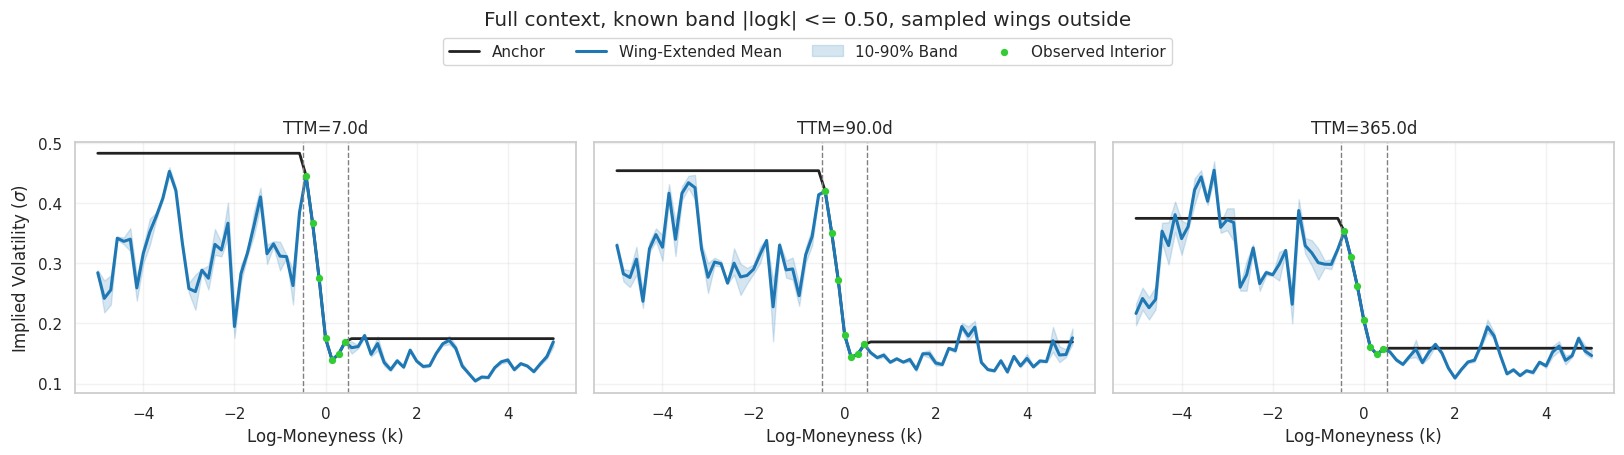

Observed share outside known band: 0.000000 (expected ~0)
full_context: avg std left wing=0.012546, right wing=0.003802


In [26]:
plot_wing_slices(
    res_full_ctx,
    title=f"Full context, known band |logk| <= {known_abs_logk:.2f}, sampled wings outside",
    ttm_indices=(1, 8, 18),
    observed_abs_logk_line=known_abs_logk,
    show_legend=True,
)

# Sanity check: observed_mask should be False outside [-0.5, 0.5] -> sampled with mask=1.
logk = res_full_ctx["logk_ext"]
observed = res_full_ctx["observed_mask"]  # True where mask=0 (fixed)
outside = logk.abs() > known_abs_logk
outside_observed_share = observed[outside].float().mean().item()
print(f"Observed share outside known band: {outside_observed_share:.6f} (expected ~0)")

# Optional quick uncertainty diagnostic in outer wings.
samples_iv = res_full_ctx["samples_iv"]
std_map = samples_iv.std(dim=0)
left_wing = logk <= -0.50
right_wing = logk >= 0.50
print(
    f"full_context: avg std left wing={std_map[left_wing].mean().item():.6f}, right wing={std_map[right_wing].mean().item():.6f}"
)